In [ ]:
%cd  /Users/sumankar/Desktop/WS_EMCAD/data


/Users/sumankar/Desktop/WS_EMCAD/data


In [10]:
!git clone https://huggingface.co/datasets/aryadomain/Medical-2D-Dataset


Cloning into 'Medical-2D-Dataset'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 124 (delta 0), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (124/124), 17.08 KiB | 8.54 MiB/s, done.


In [2]:
import os

# 1. Force kagglehub to use your exact target directory
exact_path = "/Users/sumankar/Desktop/WS_EMCAD/data"
os.environ["KAGGLEHUB_CACHE"] = exact_path
os.environ["KAGGLEHUB_CACHE_DIR"] = exact_path

# 2. Import the library after setting the path variables
import kagglehub

# 3. Create the directory safely if it does not exist yet
os.makedirs(exact_path, exist_ok=True)

# 4. Execute the download
path = kagglehub.dataset_download("moon1570/isic-2017-train-val-test-images-and-masks")
print("Dataset successfully downloaded to:", path)



/Users/sumankar/Desktop/WS_EMCAD/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Dataset successfully downloaded to: /Users/sumankar/Desktop/WS_EMCAD/data/datasets/moon1570/isic-2017-train-val-test-images-and-masks/versions/1


In [10]:
import os
import cv2
import glob
import re
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import distance_transform_edt

# ============================================================
# 1. RUNTIME HARDWARE ACCELERATION
# ============================================================
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)", flush=True)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)", flush=True)
else:
    device = torch.device("cpu")
    print("Using CPU", flush=True)

DATASET_PATH = os.path.abspath("/Users/sumankar/Desktop/WS_EMCAD/data/datasets/moon1570/isic-2017-train-val-test-images-and-masks/versions/1/ISIC2017/test")
MODEL_PATH_CANDIDATES = [
    "/Users/sumankar/Downloads/full_supervision-best_isic2017.pth",
]
MODEL_PATH = next((p for p in MODEL_PATH_CANDIDATES if os.path.exists(p)), None)
if MODEL_PATH is None:
    raise FileNotFoundError("No model checkpoint file was found.")

USE_TTA      = True
THRESHOLD    = 0.5
INPUT_SIZE   = 352

image_dir = os.path.join(DATASET_PATH, "images")
mask_dir = os.path.join(DATASET_PATH, "masks")

# ============================================================
# 2. MATCHED TRAINING FILE SYSTEM EXTRACTION SCHEME
# ============================================================
def _stem(path):
    return os.path.splitext(os.path.basename(path))[0]

def _pair_images_masks(image_root, gt_root):
    img_files = sorted([f for f in os.listdir(image_root) if f.lower().endswith(('.npy', '.jpg', '.png', '.jpeg'))])
    msk_files = sorted([f for f in os.listdir(gt_root) if f.lower().endswith(('.npy', '.jpg', '.png', '.jpeg'))])
    
    img_paths = [os.path.join(image_root, f) for f in img_files]
    msk_paths = [os.path.join(gt_root, f) for f in msk_files]
    
    img_map = {_stem(p): p for p in img_paths}
    msk_map = {_stem(p).replace('_segmentation', ''): p for p in msk_paths}
    common = sorted(set(img_map.keys()) & set(msk_map.keys()))
    
    if len(common) > 0:
        return [(img_map[k], msk_map[k]) for k in common]
    
    if len(img_paths) == len(msk_paths):
        return list(zip(img_paths, msk_paths))
    
    raise ValueError(f"Cannot match {len(img_paths)} images with {len(msk_paths)} masks")

# ============================================================
# 3. DIRECT COPIES OF TRAINING ARRAY PARSERS
# ============================================================
def load_image_matched(path):
    if path.lower().endswith('.npy'):
        arr = np.load(path, allow_pickle=True)
    else:
        arr = cv2.imread(path)
        if arr is not None:
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
        else:
            raise ValueError(f"Could not load image: {path}")

    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4) and arr.shape[-1] not in (1, 3, 4):
        arr = np.transpose(arr, (1, 2, 0))
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.ndim == 3 and arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    elif arr.ndim == 3 and arr.shape[2] > 3:
        arr = arr[:, :, :3]
        
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0:
            arr = arr * 255.0
        else:
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr

def load_mask_matched(path):
    if path.lower().endswith('.npy'):
        arr = np.load(path, allow_pickle=True)
    else:
        arr = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if arr is None:
            raise ValueError(f"Could not load mask: {path}")

    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr.squeeze(0)
        elif arr.shape[-1] == 1:
            arr = arr.squeeze(-1)
        else:
            arr = arr.max(axis=-1) if arr.shape[-1] < 10 else arr.max(axis=0)
            
    if arr.dtype == np.bool_:
        mask = arr.astype(np.uint8) * 255
    else:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0:
            mask = (arr > 0.5).astype(np.uint8) * 255
        else:
            mask = (arr > 0).astype(np.uint8) * 255
    return (mask > 127).astype(np.uint8)

# ============================================================
# 4. TRAINING SCRIPT DISTANCE METRIC REFERENCE
# ============================================================
def hd95_metric(pred_np, gt_np):
    pred = pred_np.astype(bool)
    gt   = gt_np.astype(bool)
    if not gt.any():
        return 0.0   
    if not pred.any():
        d = distance_transform_edt(~gt)
        return float(np.percentile(d[d > 0], 95)) if (d > 0).any() else 0.0
    d1 = distance_transform_edt(~pred)[gt]
    d2 = distance_transform_edt(~gt)[pred]
    return float(np.percentile(np.concatenate([d1, d2]), 95))

# Generate aligned file mappings
paired_data = _pair_images_masks(image_dir, mask_dir)
print(f"Successfully linked {len(paired_data)} cleanly mapped validation targets.", flush=True)

from lib.networks_fs import EMCADNet

model = EMCADNet(
    num_classes=1, kernel_sizes=[1,3,5], expansion_factor=2,
    dw_parallel=True, add=True, lgag_ks=3, activation='relu6',
    encoder='pvt_v2_b2', pretrain=False
)

checkpoint = torch.load(MODEL_PATH, map_location="cpu")
checkpoint = {k: v for k, v in checkpoint.items() if "total_ops" not in k and "total_params" not in k}
model.load_state_dict(checkpoint, strict=False)
model = model.to(device)
model.eval()

print("Model loaded successfully!\n", flush=True)

all_dice, all_iou, all_hd95 = [], [], []

# ============================================================
# 5. UNBUFFERED INFERENCE EVALUATION PIPELINE
# ============================================================
for idx, (img_path, msk_path) in enumerate(paired_data):
    img = load_image_matched(img_path)
    gt  = load_mask_matched(msk_path)
    
    h, w = img.shape[:2]

    # Convert to standard RGB and resize
    resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
    resized = resized.astype(np.float32) / 255.0
        
    # Apply baseline validation ImageNet standardization parameters
    resized = (resized - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    tensor = torch.tensor(resized).permute(2,0,1).unsqueeze(0).float().to(device)
    
    with torch.no_grad():
        p1 = model(tensor)
        if isinstance(p1, list): 
            p1 = p1[-1]

        if USE_TTA:
            flipped = torch.flip(tensor, dims=[3])
            p2 = model(flipped)
            if isinstance(p2, list): 
                p2 = p2[-1]
            p2 = torch.flip(p2, dims=[3])
            pred = (p1 + p2) / 2.0
        else:
            pred = p1

        pred = F.interpolate(pred, size=(h, w), mode='bilinear', align_corners=False)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()

    pred_mask = (pred >= THRESHOLD).astype(np.uint8)

    # Core statistical processing
    intersection = (pred_mask * gt).sum()
    dice = (2 * intersection + 1e-8) / (pred_mask.sum() + gt.sum() + 1e-8)
    union = pred_mask.sum() + gt.sum() - intersection
    iou = (intersection + 1e-8) / (union + 1e-8)

    hd = hd95_metric(pred_mask, gt)

    all_dice.append(dice)
    all_iou.append(iou)
    all_hd95.append(hd)

    print(f"[{idx+1}/{len(paired_data)}] {os.path.basename(img_path):25s} Dice={dice:.4f} IoU={iou:.4f} HD95={hd:.2f}", flush=True)

# ============================================================
# 6. PERFORMANCE AGGREGATIONS (WITH ADDED MEDIAN IOU)
# ============================================================
print("\nMetrics Summary")
print(f"Mean Dice ↑  : {np.mean(all_dice):.4f}")
print(f"Median Dice ↑: {np.median(all_dice):.4f}")
print(f"Std Dice ↓   : {np.std(all_dice):.4f}")
print(f"Mean IoU ↑   : {np.mean(all_iou):.4f}")
print(f"Median IoU ↑ : {np.median(all_iou):.4f}")
print(f"Mean HD95 ↓  : {np.mean(all_hd95):.4f}")
print(f"Median HD95 ↓: {np.median(all_hd95):.4f}")


Using Apple Silicon GPU (MPS)
Successfully linked 600 cleanly mapped validation targets.
Model loaded successfully!

[1/600] ISIC_0012086.jpg          Dice=0.2341 IoU=0.1326 HD95=790.71
[2/600] ISIC_0012092.jpg          Dice=0.9070 IoU=0.8298 HD95=28.07
[3/600] ISIC_0012095.jpg          Dice=0.8907 IoU=0.8030 HD95=18.03
[4/600] ISIC_0012134.jpg          Dice=0.8049 IoU=0.6735 HD95=232.77
[5/600] ISIC_0012136.jpg          Dice=0.7334 IoU=0.5790 HD95=262.98
[6/600] ISIC_0012147.jpg          Dice=0.7744 IoU=0.6319 HD95=55.46
[7/600] ISIC_0012149.jpg          Dice=0.8630 IoU=0.7591 HD95=41.15
[8/600] ISIC_0012152.jpg          Dice=0.9471 IoU=0.8995 HD95=1.00
[9/600] ISIC_0012178.jpg          Dice=0.7315 IoU=0.5766 HD95=102.88
[10/600] ISIC_0012199.jpg          Dice=0.9286 IoU=0.8668 HD95=5.00
[11/600] ISIC_0012207.jpg          Dice=0.8151 IoU=0.6880 HD95=92.31
[12/600] ISIC_0012215.jpg          Dice=0.7102 IoU=0.5506 HD95=337.04
[13/600] ISIC_0012216.jpg          Dice=0.7477 IoU=0.5971 HD9

In [10]:
import os
import cv2
import glob
import re
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import distance_transform_edt

# ============================================================
# 1. RUNTIME HARDWARE ACCELERATION
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)", flush=True)
else:
    device = torch.device("cpu")
    print("Using CPU", flush=True)

DATASET_PATH      = "/Users/sumankar/Desktop/WS_EMCAD/data/kvasir/test"
MODEL_PATH        = "/Users/sumankar/Downloads/ws_hupanno-best_kvasir_morph_1.pth"  # FIXED
USE_TTA           = True
THRESHOLD         = 0.5
INPUT_SIZE        = 352

image_dir = os.path.join(DATASET_PATH, "images")
mask_dir  = os.path.join(DATASET_PATH, "masks")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

# ============================================================
# 2. FILE SYSTEM EXTRACTION SCHEME
# ============================================================
def _stem(path):
    return os.path.splitext(os.path.basename(path))[0]

def _pair_images_masks(image_root, gt_root):
    img_files = sorted([f for f in os.listdir(image_root)
                        if f.lower().endswith('.npy')])
    msk_files = sorted([f for f in os.listdir(gt_root)
                        if f.lower().endswith('.npy')])
    
    img_paths = [os.path.join(image_root, f) for f in img_files]
    msk_paths = [os.path.join(gt_root,     f) for f in msk_files]
    
    img_map = {_stem(p): p for p in img_paths}
    msk_map = {_stem(p): p for p in msk_paths}
    common  = sorted(set(img_map.keys()) & set(msk_map.keys()))
    
    if len(common) > 0:
        return [(img_map[k], msk_map[k]) for k in common]
    
    if len(img_paths) == len(msk_paths):
        return list(zip(img_paths, msk_paths))
    
    raise ValueError(f"Cannot match {len(img_paths)} images "
                     f"with {len(msk_paths)} masks")

# ============================================================
# 3. ARRAY PARSERS
# ============================================================
def load_image_matched(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4) \
       and arr.shape[-1] not in (1, 3, 4):
        arr = np.transpose(arr, (1, 2, 0))
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.ndim == 3 and arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    elif arr.ndim == 3 and arr.shape[2] > 3:
        arr = arr[:, :, :3]
        
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0:
            arr = arr * 255.0
        else:
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr

def load_mask_matched(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr.squeeze(0)
        elif arr.shape[-1] == 1:
            arr = arr.squeeze(-1)
        else:
            arr = arr.max(axis=-1) if arr.shape[-1] < 10 else arr.max(axis=0)
            
    if arr.dtype == np.bool_:
        mask = arr.astype(np.uint8) * 255
    else:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0:
            mask = (arr > 0.5).astype(np.uint8) * 255
        else:
            mask = (arr > 0).astype(np.uint8) * 255
    return (mask > 127).astype(np.uint8)

# ============================================================
# 4. HD95 METRIC
# ============================================================
def hd95_metric(pred_np, gt_np):
    pred = pred_np.astype(bool)
    gt   = gt_np.astype(bool)
    if not gt.any():
        return 0.0   
    if not pred.any():
        d = distance_transform_edt(~gt)
        return float(np.percentile(d[d > 0], 95)) \
               if (d > 0).any() else 0.0
    d1 = distance_transform_edt(~pred)[gt]
    d2 = distance_transform_edt(~gt)[pred]
    return float(np.percentile(np.concatenate([d1, d2]), 95))

# ============================================================
# 5. LOAD MODEL
# ============================================================
paired_data = _pair_images_masks(image_dir, mask_dir)
print(f"Linked {len(paired_data)} image–mask pairs.", flush=True)

from lib.networks_hup import EMCADNet

# FIXED: use_morph=True so MorphWrapper weights can be loaded
model = EMCADNet(
    num_classes      = 1,
    kernel_sizes     = [1, 3, 5],
    expansion_factor = 2,
    dw_parallel      = True,
    add              = True,
    lgag_ks          = 3,
    activation       = 'relu6',
    encoder          = 'pvt_v2_b2',
    pretrain         = False,
    use_morph        = True,     # ← MATCH YOUR TRAINING
    morph_sample_k   = 4,        # ← MATCH YOUR TRAINING
)

checkpoint = torch.load(MODEL_PATH, map_location="cpu")
# Remove any non-parameter keys
checkpoint = {k: v for k, v in checkpoint.items()
              if "total_ops" not in k
              and "total_params" not in k}
model.load_state_dict(checkpoint, strict=False)
model = model.to(device)
model.eval()

print("Model loaded successfully!\n", flush=True)

# ============================================================
# 6. INFERENCE LOOP
# ============================================================
all_dice, all_iou, all_hd95 = [], [], []

for idx, (img_path, msk_path) in enumerate(paired_data):
    img = load_image_matched(img_path)
    gt  = load_mask_matched(msk_path)
    
    h, w = img.shape[:2]

    # Resize and normalise
    resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
    resized = resized.astype(np.float32) / 255.0
    resized = (resized - [0.485, 0.456, 0.406]) \
            /  [0.229, 0.224, 0.225]
    tensor = torch.tensor(resized)\
             .permute(2, 0, 1)\
             .unsqueeze(0)\
             .float()\
             .to(device)
    
    with torch.no_grad():
        # FIXED: mode='test' → returns list of preds
        p1 = model(tensor, mode='test')
        if isinstance(p1, list):
            p1 = p1[-1]      # finest-scale prediction

        if USE_TTA:
            flipped = torch.flip(tensor, dims=[3])
            p2 = model(flipped, mode='test')
            if isinstance(p2, list):
                p2 = p2[-1]
            p2 = torch.flip(p2, dims=[3])
            pred = (p1 + p2) / 2.0
        else:
            pred = p1

        pred = F.interpolate(pred, size=(h, w),
                             mode='bilinear', align_corners=False)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()

    pred_mask = (pred >= THRESHOLD).astype(np.uint8)

    # Metrics
    intersection = (pred_mask * gt).sum()
    dice = (2 * intersection + 1e-8) \
         / (pred_mask.sum() + gt.sum() + 1e-8)
    union = pred_mask.sum() + gt.sum() - intersection
    iou  = (intersection + 1e-8) / (union + 1e-8)
    hd   = hd95_metric(pred_mask, gt)

    all_dice.append(dice)
    all_iou.append(iou)
    all_hd95.append(hd)

    print(f"[{idx+1}/{len(paired_data)}] "
          f"{os.path.basename(img_path):25s} "
          f"Dice={dice:.4f} IoU={iou:.4f} HD95={hd:.2f}",
          flush=True)

# ============================================================
# 7. SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"  TEST RESULTS")
print(f"{'='*60}")
print(f"  Samples       : {len(all_dice)}")
print(f"  Mean   Dice ↑ : {np.mean(all_dice):.4f}")
print(f"  Median Dice ↑ : {np.median(all_dice):.4f}")
print(f"  Std    Dice   : {np.std(all_dice):.4f}")
print(f"  Mean   IoU  ↑ : {np.mean(all_iou):.4f}")
print(f"  Median IoU  ↑ : {np.median(all_iou):.4f}")
print(f"  Mean   HD95 ↓ : {np.mean(all_hd95):.2f}")
print(f"  Median HD95 ↓ : {np.median(all_hd95):.2f}")
print(f"{'='*60}")

Using CPU
Linked 100 image–mask pairs.
Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder (use_morph=True, K=4): 3,201,655 params
Model loaded successfully!

[1/100] slice_0000.npy            Dice=0.9084 IoU=0.8321 HD95=5.00
[2/100] slice_0001.npy            Dice=0.9678 IoU=0.9376 HD95=0.00
[3/100] slice_0002.npy            Dice=0.9588 IoU=0.9209 HD95=0.00
[4/100] slice_0003.npy            Dice=0.8291 IoU=0.7080 HD95=9.43
[5/100] slice_0004.npy            Dice=0.9542 IoU=0.9124 HD95=0.00
[6/100] slice_0005.npy            Dice=0.9727 IoU=0.9469 HD95=0.00
[7/100] slice_0006.npy            Dice=0.9418 IoU=0.8900 HD95=1.00
[8/100] slice_0007.npy            Dice=0.8638 IoU=0.7602 HD95=21.00
[9/100] slice_0008.npy            Dice=0.9616 IoU=0.9260 HD95=0.00
[10/100] slice_0009.npy            Dice=0.9597 IoU=0.9225 HD95=0.00
[11/100] slice_0010.npy            Dice=0.9420 IoU=0.8904 HD95=1.00
[12/100] slice_0011.npy            Dice=0.9660 IoU=0.9342 HD95=0.00
[13/100] slice_0012.npy          

In [12]:
"""
hupanno_viz.py
Visualizes the HUPAnno annotation structure:
Original GT | Inner Ω_I | Outer Ω_O | Uncertain Ring Ω_Δ | LRP Patches | 4-class map
Critical figure for explaining your annotation contribution.
"""

import os, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import sys
sys.path.append('.')
from utils.dataloader_hup import generate_hupanno

DATASET_PATH = "/Users/sumankar/Desktop/WS_EMCAD/data/kvasir/test"
OUTPUT_DIR   = "./figures"
N_SAMPLES    = 3
DPI          = 300
os.makedirs(OUTPUT_DIR, exist_ok=True)

def _stem(p): return os.path.splitext(os.path.basename(p))[0]

def load_image(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim==3 and arr.shape[0] in (1,3,4) and arr.shape[-1] not in (1,3,4):
        arr = np.transpose(arr,(1,2,0))
    if arr.ndim==2: arr = np.stack([arr]*3,-1)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        arr = arr*255 if arr.max()<=1 else \
              (arr-arr.min())/(arr.max()-arr.min()+1e-8)*255
        arr = np.clip(arr,0,255).astype(np.uint8)
    return arr[:,:,:3]

def load_mask(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim==3: arr = arr.squeeze()
    arr = arr.astype(np.float32)
    return (arr>0.5).astype(np.float32) if arr.max()<=1 \
           else (arr>0).astype(np.float32)

img_dir = os.path.join(DATASET_PATH,"images")
msk_dir = os.path.join(DATASET_PATH,"masks")
imgs = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])[:N_SAMPLES]

fig, axes = plt.subplots(N_SAMPLES, 6, figsize=(22, 3.6*N_SAMPLES))
if N_SAMPLES == 1: axes = axes[None, :]

titles = ['Input + GT contour', r'Inner Envelope $\Omega_I$',
          r'Outer Envelope $\Omega_O$', r'Uncertain Ring $\Omega_\Delta$',
          'LRP Patches', '4-Class CCG Map $y_c$']

# 4-class colormap
cmap4 = ListedColormap([
    '#1a1a1a',   # 0: certain BG    — dark
    '#FFA500',   # 1: global uncert — orange
    '#FF1493',   # 2: LRP uncert    — pink
    '#00FF7F',   # 3: certain FG    — green
])

for row, fname in enumerate(imgs):
    img = load_image(os.path.join(img_dir, fname))
    gt  = load_mask(os.path.join(msk_dir, fname))

    (y_in, y_out, omega_delta,
     lrp_fg, lrp_bg, lrp_unc, lrp_mask, y_c) = generate_hupanno(gt, K=2)

    # Col 0 — image with GT contour
    ov = img.copy()
    c,_ = cv2.findContours((gt*255).astype(np.uint8),
                           cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov, c, -1, (255,255,0), 3)
    axes[row,0].imshow(ov); axes[row,0].axis('off')

    # Col 1 — inner envelope
    axes[row,1].imshow(y_in, cmap='Greens', vmin=0, vmax=1)
    axes[row,1].axis('off')

    # Col 2 — outer envelope
    axes[row,2].imshow(y_out, cmap='Blues', vmin=0, vmax=1)
    axes[row,2].axis('off')

    # Col 3 — uncertain ring
    axes[row,3].imshow(omega_delta, cmap='Oranges', vmin=0, vmax=1)
    axes[row,3].axis('off')

    # Col 4 — LRP patches (fg/bg/uncertain composite)
    lrp_viz = np.zeros((*gt.shape,3))
    lrp_viz[lrp_fg  > 0.5] = [0.0, 1.0, 0.5]   # LRP FG   — green
    lrp_viz[lrp_unc > 0.5] = [1.0, 0.1, 0.6]   # LRP unc  — pink
    lrp_viz[(lrp_bg>0.5)&(lrp_mask>0.5)] = [0.2,0.4,1.0]  # LRP BG
    axes[row,4].imshow(lrp_viz); axes[row,4].axis('off')

    # Col 5 — 4-class map
    axes[row,5].imshow(y_c, cmap=cmap4, vmin=0, vmax=3)
    axes[row,5].axis('off')

    # Area stats
    axes[row,0].text(-0.06, 0.5,
        f'$\\Omega_I$: {int(y_in.sum())}px\n'
        f'$\\Omega_\\Delta$: {int(omega_delta.sum())}px\n'
        f'LRP: {int(lrp_mask.sum())}px',
        transform=axes[row,0].transAxes, rotation=90,
        va='center', ha='center', fontsize=10, fontweight='bold')

for col, t in enumerate(titles):
    axes[0,col].set_title(t, fontsize=14, fontweight='bold', pad=12)

legend = [
    mpatches.Patch(color='#1a1a1a', label='Class 0: Certain Background'),
    mpatches.Patch(color='#FFA500', label='Class 1: Global Uncertain'),
    mpatches.Patch(color='#FF1493', label='Class 2: LRP Uncertain'),
    mpatches.Patch(color='#00FF7F', label='Class 3: Certain Foreground'),
]
fig.legend(handles=legend, loc='lower center', ncol=4,
           fontsize=12, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0.02,0.03,1,1])
plt.savefig(f'{OUTPUT_DIR}/hupanno_annotation.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/hupanno_annotation.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/hupanno_annotation.png / .pdf")
plt.close()

Saved: ./figures/hupanno_annotation.png / .pdf


In [13]:
"""
metrics_plots.py
Publication-quality metric analysis:
- Dice/IoU/HD95 distribution histograms
- Box plots
- Cumulative distribution (what % achieve Dice > X)
- Scatter: Dice vs polyp size
"""

import os, cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import distance_transform_edt

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

DATASET_PATH = "/Users/sumankar/Desktop/WS_EMCAD/data/kvasir/test"
MODEL_PATH   = "/Users/sumankar/Downloads/ws_hupanno-best_kvasir_morph_1.pth"
OUTPUT_DIR   = "./figures"
INPUT_SIZE   = 352
THRESHOLD    = 0.5
DPI          = 300
os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── (reuse loaders from Script 1) ───────────────────────────
exec(open(__file__).read().split('# ── MODEL')[0]) \
    if False else None   # placeholder — copy helpers from Script 1

def _stem(p): return os.path.splitext(os.path.basename(p))[0]
def _pair(ir, gr):
    i = sorted([f for f in os.listdir(ir) if f.endswith('.npy')])
    m = sorted([f for f in os.listdir(gr) if f.endswith('.npy')])
    return [(os.path.join(ir,a), os.path.join(gr,b)) for a,b in zip(i,m)]

def load_image(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim==3 and arr.shape[0] in (1,3,4) and arr.shape[-1] not in (1,3,4):
        arr = np.transpose(arr,(1,2,0))
    if arr.ndim==2: arr = np.stack([arr]*3,-1)
    if arr.dtype!=np.uint8:
        arr = arr.astype(np.float32)
        arr = arr*255 if arr.max()<=1 else \
              (arr-arr.min())/(arr.max()-arr.min()+1e-8)*255
        arr = np.clip(arr,0,255).astype(np.uint8)
    return arr[:,:,:3]

def load_mask(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim==3: arr = arr.squeeze()
    arr = arr.astype(np.float32)
    return ((arr>0.5) if arr.max()<=1 else (arr>0)).astype(np.uint8)

def hd95_metric(p, g):
    p, g = p.astype(bool), g.astype(bool)
    if not g.any(): return 0.
    if not p.any():
        d = distance_transform_edt(~g)
        return float(np.percentile(d[d>0],95)) if (d>0).any() else 0.
    return float(np.percentile(np.concatenate([
        distance_transform_edt(~p)[g],
        distance_transform_edt(~g)[p]]), 95))

from lib.networks_hup import EMCADNet
model = EMCADNet(num_classes=1, kernel_sizes=[1,3,5],
                 expansion_factor=2, dw_parallel=True, add=True,
                 lgag_ks=3, activation='relu6', encoder='pvt_v2_b2',
                 pretrain=False, use_morph=True, morph_sample_k=4)
ck = torch.load(MODEL_PATH, map_location="cpu")
ck = {k:v for k,v in ck.items()
      if "total_ops" not in k and "total_params" not in k}
model.load_state_dict(ck, strict=False)
model = model.to(device).eval()

MEAN = np.array([0.485,0.456,0.406],dtype=np.float32)
STD  = np.array([0.229,0.224,0.225],dtype=np.float32)

pairs = _pair(os.path.join(DATASET_PATH,"images"),
              os.path.join(DATASET_PATH,"masks"))

dices, ious, hds, areas = [], [], [], []
for ip, mp in pairs:
    img = load_image(ip); gt = load_mask(mp)
    h,w = img.shape[:2]
    r = cv2.resize(img,(INPUT_SIZE,INPUT_SIZE)).astype(np.float32)/255.
    r = (r-MEAN)/STD
    t = torch.tensor(r).permute(2,0,1).unsqueeze(0).float().to(device)
    with torch.no_grad():
        p = model(t, mode='test'); p = p[-1] if isinstance(p,list) else p
        pf = model(torch.flip(t,dims=[3]), mode='test')
        pf = pf[-1] if isinstance(pf,list) else pf
        p = (p + torch.flip(pf,dims=[3]))/2.
        p = F.interpolate(p,size=(h,w),mode='bilinear',align_corners=False)
        p = torch.sigmoid(p).squeeze().cpu().numpy()
    pm = (p>=THRESHOLD).astype(np.uint8)
    inter = (pm*gt).sum()
    dices.append((2*inter+1e-8)/(pm.sum()+gt.sum()+1e-8))
    ious.append((inter+1e-8)/(pm.sum()+gt.sum()-inter+1e-8))
    hds.append(hd95_metric(pm,gt))
    areas.append(gt.sum()/(gt.shape[0]*gt.shape[1])*100)  # % of image

dices, ious, hds, areas = map(np.array,(dices,ious,hds,areas))

# ── FIGURE ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# 1. Dice histogram
ax = axes[0,0]
ax.hist(dices, bins=25, color='#2E86AB', edgecolor='black', alpha=0.8)
ax.axvline(dices.mean(), color='red', ls='--', lw=2.5,
           label=f'Mean = {dices.mean():.4f}')
ax.axvline(np.median(dices), color='green', ls='--', lw=2.5,
           label=f'Median = {np.median(dices):.4f}')
ax.set_xlabel('Dice Coefficient'); ax.set_ylabel('Frequency')
ax.set_title('Dice Score Distribution', fontweight='bold', fontsize=14)
ax.legend()

# 2. IoU histogram
ax = axes[0,1]
ax.hist(ious, bins=25, color='#A23B72', edgecolor='black', alpha=0.8)
ax.axvline(ious.mean(), color='red', ls='--', lw=2.5,
           label=f'Mean = {ious.mean():.4f}')
ax.axvline(np.median(ious), color='green', ls='--', lw=2.5,
           label=f'Median = {np.median(ious):.4f}')
ax.set_xlabel('IoU'); ax.set_ylabel('Frequency')
ax.set_title('IoU Distribution', fontweight='bold', fontsize=14)
ax.legend()

# 3. HD95 histogram (log scale)
ax = axes[0,2]
ax.hist(hds[hds<50], bins=25, color='#F18F01',
        edgecolor='black', alpha=0.8)
ax.axvline(hds.mean(), color='red', ls='--', lw=2.5,
           label=f'Mean = {hds.mean():.2f} px')
ax.axvline(np.median(hds), color='green', ls='--', lw=2.5,
           label=f'Median = {np.median(hds):.2f} px')
ax.set_xlabel('HD95 (pixels)'); ax.set_ylabel('Frequency')
ax.set_title('HD95 Distribution', fontweight='bold', fontsize=14)
ax.legend()

# 4. Box plots
ax = axes[1,0]
bp = ax.boxplot([dices, ious], labels=['Dice','IoU'],
                patch_artist=True, widths=0.6,
                medianprops=dict(color='red', linewidth=2.5))
for patch, c in zip(bp['boxes'], ['#2E86AB','#A23B72']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('Score')
ax.set_title('Overlap Metrics', fontweight='bold', fontsize=14)
ax.set_ylim(0,1.05)

# 5. Cumulative distribution
ax = axes[1,1]
srt = np.sort(dices)
cdf = np.arange(1,len(srt)+1)/len(srt)*100
ax.plot(srt, cdf, lw=3, color='#2E86AB')
for thr in [0.8, 0.85, 0.9, 0.95]:
    pct = (dices >= thr).mean()*100
    ax.axvline(thr, ls=':', color='gray', alpha=0.6)
    ax.text(thr, 50, f'  {pct:.0f}%\n  ≥{thr}',
            rotation=90, va='center', fontsize=10)
ax.set_xlabel('Dice Threshold')
ax.set_ylabel('% of samples achieving ≥ threshold')
ax.set_title('Cumulative Performance', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)

# 6. Dice vs polyp size
ax = axes[1,2]
sc = ax.scatter(areas, dices, c=hds, cmap='coolwarm_r',
                s=60, alpha=0.75, edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='HD95 (px)')
ax.set_xlabel('Polyp Area (% of image)')
ax.set_ylabel('Dice Coefficient')
ax.set_title('Performance vs Lesion Size', fontweight='bold', fontsize=14)
ax.set_xscale('log')
# trend line
z = np.polyfit(np.log10(areas+1e-6), dices, 1)
xs = np.logspace(np.log10(areas.min()), np.log10(areas.max()), 100)
ax.plot(xs, np.poly1d(z)(np.log10(xs)), 'r--', lw=2, alpha=0.7,
        label='Trend')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_analysis.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/metrics_analysis.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/metrics_analysis.png / .pdf")
plt.close()

# ── Print stats table for paper ─────────────────────────────
print(f"\n{'='*62}")
print(f"  METRICS TABLE (for paper)")
print(f"{'='*62}")
print(f"  {'Metric':<12} {'Mean':>10} {'Median':>10} "
      f"{'Std':>10} {'Min':>9} {'Max':>9}")
print(f"  {'-'*58}")
print(f"  {'Dice':<12} {dices.mean():>10.4f} {np.median(dices):>10.4f} "
      f"{dices.std():>10.4f} {dices.min():>9.4f} {dices.max():>9.4f}")
print(f"  {'IoU':<12} {ious.mean():>10.4f} {np.median(ious):>10.4f} "
      f"{ious.std():>10.4f} {ious.min():>9.4f} {ious.max():>9.4f}")
print(f"  {'HD95 (px)':<12} {hds.mean():>10.2f} {np.median(hds):>10.2f} "
      f"{hds.std():>10.2f} {hds.min():>9.2f} {hds.max():>9.2f}")
print(f"{'='*62}")
print(f"\n  Samples with Dice ≥ 0.90 : {(dices>=0.90).sum()}/{len(dices)} "
      f"({(dices>=0.90).mean()*100:.1f}%)")
print(f"  Samples with Dice ≥ 0.85 : {(dices>=0.85).sum()}/{len(dices)} "
      f"({(dices>=0.85).mean()*100:.1f}%)")
print(f"  Samples with HD95 ≤ 5 px : {(hds<=5).sum()}/{len(hds)} "
      f"({(hds<=5).mean()*100:.1f}%)")

Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder (use_morph=True, K=4): 3,201,655 params


/var/folders/ls/k2yjsntx5rb_t_hlwq8n6rbw0000gn/T/ipykernel_5842/1497870549.py:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([dices, ious], labels=['Dice','IoU'],


Saved: ./figures/metrics_analysis.png / .pdf

  METRICS TABLE (for paper)
  Metric             Mean     Median        Std       Min       Max
  ----------------------------------------------------------
  Dice             0.9227     0.9604     0.1018    0.4597    0.9836
  IoU              0.8697     0.9239     0.1412    0.2985    0.9677
  HD95 (px)          5.74       0.00      15.58      0.00     77.03

  Samples with Dice ≥ 0.90 : 83/100 (83.0%)
  Samples with Dice ≥ 0.85 : 88/100 (88.0%)
  Samples with HD95 ≤ 5 px : 84/100 (84.0%)


In [14]:
"""
morph_field_viz.py  — FIXED
Visualizes what MorphWrapper actually learned:
- Offset magnitude heatmaps
- Offset direction (quiver/arrow) plots  
- Attention weight maps per sampling head
- Before/after warping comparison
"""

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATASET_PATH = "/Users/sumankar/Desktop/WS_EMCAD/data/kvasir/test"
MODEL_PATH   = "/Users/sumankar/Downloads/ws_hupanno-best_kvasir_morph_1.pth"
OUTPUT_DIR   = "./figures"
INPUT_SIZE   = 352
DPI          = 300
SAMPLE_IDX   = 0

os.makedirs(OUTPUT_DIR, exist_ok=True)

# CPU only on Mac (avoid MPS grid_sample border issue)
device = torch.device("cpu")
print(f"Using device: {device}")

# ============================================================
# DATA HELPERS
# ============================================================
def load_image(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim == 3 and arr.shape[0] in (1,3,4) \
       and arr.shape[-1] not in (1,3,4):
        arr = np.transpose(arr, (1,2,0))
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.ndim == 3 and arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    elif arr.ndim == 3 and arr.shape[2] > 3:
        arr = arr[:, :, :3]
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        arr = arr*255.0 if arr.max() <= 1.0 else \
              (arr-arr.min())/(arr.max()-arr.min()+1e-8)*255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr[:, :, :3]

# ============================================================
# LOAD MODEL
# ============================================================
from lib.networks_hup import EMCADNet

model = EMCADNet(
    num_classes=1, kernel_sizes=[1,3,5],
    expansion_factor=2, dw_parallel=True, add=True,
    lgag_ks=3, activation='relu6', encoder='pvt_v2_b2',
    pretrain=False, use_morph=True, morph_sample_k=4,
)
ckpt = torch.load(MODEL_PATH, map_location="cpu")
ckpt = {k: v for k, v in ckpt.items()
        if "total_ops" not in k and "total_params" not in k}
model.load_state_dict(ckpt, strict=False)
model = model.to(device).eval()
print("Model loaded.")

# ============================================================
# HOOKS — FIXED
# The hook receives inp as positional args tuple.
# MorphWrapper.forward(self, g, x) → inp = (g, x)
# So inp[0] = g, inp[1] = x  BUT only if called as
# module(g, x).  Since EMCAD calls self.morph3(g=d3, x=skips[0])
# as keyword args, inp may be EMPTY and kwargs holds them.
# Fix: use **kwargs fallback.
# ============================================================
captured = {}

def make_hook(stage_name):
    def hook(module, inp, out):
        # ── Safely extract g and x ────────────────────────────
        # Called as: self.morph3(g=d3, x=skips[0])
        # → inp = ()  (empty, because keyword args)
        # → kwargs not available in standard hook
        # Solution: rerun forward manually with stored inputs
        # via a pre-hook that captures inputs first.
        pass  # placeholder — we use pre-hook below
    return hook

def make_pre_hook(stage_name):
    def pre_hook(module, args, kwargs):
        """
        forward_pre_hook with kwargs support (PyTorch >= 1.13)
        Captures g and x before forward runs.
        """
        # args may be empty if called with keyword args
        if len(args) >= 2:
            g_in = args[0]
            x_in = args[1]
        elif len(args) == 1:
            g_in = args[0]
            x_in = kwargs.get('x', None)
        else:
            g_in = kwargs.get('g', None)
            x_in = kwargs.get('x', None)

        if g_in is None or x_in is None:
            return   # cannot capture

        captured[stage_name + '_inputs'] = {
            'g': g_in.detach().cpu(),
            'x': x_in.detach().cpu(),
        }
    return pre_hook

def make_out_hook(stage_name):
    def hook(module, inp, out):
        """Captures output x_warped."""
        captured[stage_name + '_output'] = out.detach().cpu()
    return hook

# Register hooks
for sname in ['morph3', 'morph2', 'morph1']:
    m = getattr(model.decoder, sname)

    # Pre-hook: capture inputs (g, x)
    try:
        # PyTorch >= 1.13 supports with_kwargs=True
        m.register_forward_pre_hook(
            make_pre_hook(sname), with_kwargs=True
        )
    except TypeError:
        # Older PyTorch — register without kwargs
        def make_pre_hook_old(sn):
            def pre_hook(module, args):
                if len(args) >= 2:
                    captured[sn + '_inputs'] = {
                        'g': args[0].detach().cpu(),
                        'x': args[1].detach().cpu(),
                    }
            return pre_hook
        m.register_forward_pre_hook(make_pre_hook_old(sname))

    # Post-hook: capture output
    m.register_forward_hook(make_out_hook(sname))

print("Hooks registered.")

# ============================================================
# LOAD ONE TEST IMAGE AND RUN FORWARD
# ============================================================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img_dir = os.path.join(DATASET_PATH, "images")
img_files = sorted([f for f in os.listdir(img_dir)
                    if f.endswith('.npy')])

img = load_image(os.path.join(img_dir, img_files[SAMPLE_IDX]))
print(f"Loaded image: {img_files[SAMPLE_IDX]}  shape={img.shape}")

r = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE)).astype(np.float32)/255.0
r = (r - MEAN) / STD
t = torch.tensor(r).permute(2,0,1).unsqueeze(0).float().to(device)

with torch.no_grad():
    out = model(t, mode='test')
    print(f"Forward done. Pred shape: {out[-1].shape}")
    print(f"Captured stages: {[k for k in captured.keys()]}")

# ============================================================
# HELPER: compute offsets + attention from captured inputs
# ============================================================
def get_morph_fields(module, stage_name):
    """Recompute MFE output from captured g and x."""
    inp = captured.get(stage_name + '_inputs')
    if inp is None:
        print(f"WARNING: no inputs captured for {stage_name}")
        return None

    g = inp['g'].to(device)
    x = inp['x'].to(device)
    B, C, H, W = x.shape

    with torch.no_grad():
        # Align g to x
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=(H, W),
                              mode='bilinear', align_corners=False)
        if not isinstance(module.g_proj, torch.nn.Identity):
            g_al = module.g_proj(g)
        else:
            g_al = g

        oa = module.mfe(torch.cat([g_al, x], dim=1))
        K  = module.sample_k

        raw_offsets = oa[:, :K*2, :, :]     # [B, K*2, H, W]
        raw_att     = oa[:, K*2:,  :, :]    # [B, K,   H, W]
        att_maps    = F.softmax(raw_att, dim=1)

        # Reshape offsets to [B, K, 2, H, W]
        offsets = raw_offsets.reshape(B, K, 2, H, W)

    return {
        'offsets'  : offsets.cpu().numpy(),     # [B, K, 2, H, W]
        'att_maps' : att_maps.cpu().numpy(),    # [B, K, H, W]
        'x'        : x.cpu().numpy(),           # [B, C, H, W]
        'x_warped' : captured.get(
                         stage_name + '_output',
                         torch.zeros_like(x)
                     ).cpu().numpy(),            # [B, C, H, W]
        'H': H, 'W': W, 'K': K, 'C': C,
    }

# ============================================================
# FIGURE 1: Offset Magnitude + Direction + Attention Maps
# ============================================================
stages       = ['morph3', 'morph2', 'morph1']
stage_labels = [
    'Stage 3\n(C=320, 22×22)',
    'Stage 2\n(C=128, 44×44)',
    'Stage 1\n(C=64,  88×88)',
]

fig, axes = plt.subplots(3, 6, figsize=(22, 11))
col_titles = ['Input\n(at stage res)',
              'Offset Magnitude\n$\\|\\Delta\\|$ avg over K',
              'Warp Direction\n(quiver)',
              'Attn Head 1\n$A_1$',
              'Attn Head 2\n$A_2$',
              'Attn Head 3+4\n$(A_3+A_4)/2$']

for row, (sname, slabel) in enumerate(zip(stages, stage_labels)):
    module = getattr(model.decoder, sname)
    d = get_morph_fields(module, sname)

    if d is None:
        for col in range(6):
            axes[row,col].text(0.5, 0.5, 'No data',
                               ha='center', va='center')
            axes[row,col].axis('off')
        continue

    offsets = d['offsets'][0]    # [K, 2, H, W]
    att     = d['att_maps'][0]   # [K, H, W]
    H, W, K = d['H'], d['W'], d['K']

    # ── Col 0: image at stage resolution ──────────────────
    img_s = cv2.resize(img, (W, H))
    axes[row,0].imshow(img_s)
    axes[row,0].axis('off')
    axes[row,0].text(-0.12, 0.5, slabel,
                     transform=axes[row,0].transAxes,
                     rotation=90, va='center', ha='center',
                     fontsize=11, fontweight='bold')

    # ── Col 1: offset magnitude ────────────────────────────
    mag = np.sqrt(offsets[:,0]**2 + offsets[:,1]**2).mean(0)  # [H,W]
    im1 = axes[row,1].imshow(mag, cmap='inferno')
    axes[row,1].axis('off')
    plt.colorbar(im1, ax=axes[row,1], fraction=0.046, pad=0.04,
                 label='px')

    # ── Col 2: quiver direction ────────────────────────────
    axes[row,2].imshow(img_s, alpha=0.55)
    step = max(1, H//14)
    ys, xs = np.mgrid[0:H:step, 0:W:step]
    dx = offsets[:,0].mean(0)[::step, ::step]   # avg over K
    dy = offsets[:,1].mean(0)[::step, ::step]
    axes[row,2].quiver(xs, ys, dx, dy,
                       color='cyan', alpha=0.9,
                       scale=None, scale_units='xy',
                       angles='xy', width=0.006,
                       headwidth=4)
    axes[row,2].set_xlim(0,W); axes[row,2].set_ylim(H,0)
    axes[row,2].axis('off')

    # ── Col 3: attention head 1 ────────────────────────────
    im3 = axes[row,3].imshow(att[0], cmap='viridis',
                              vmin=0, vmax=att.max())
    axes[row,3].axis('off')
    plt.colorbar(im3, ax=axes[row,3], fraction=0.046, pad=0.04)

    # ── Col 4: attention head 2 ────────────────────────────
    if K > 1:
        im4 = axes[row,4].imshow(att[1], cmap='viridis',
                                  vmin=0, vmax=att.max())
        axes[row,4].axis('off')
        plt.colorbar(im4, ax=axes[row,4], fraction=0.046, pad=0.04)
    else:
        axes[row,4].axis('off')

    # ── Col 5: attention heads 3+4 averaged ───────────────
    if K > 2:
        avg_att = att[2:].mean(0)
        im5 = axes[row,5].imshow(avg_att, cmap='viridis',
                                  vmin=0, vmax=att.max())
        axes[row,5].axis('off')
        plt.colorbar(im5, ax=axes[row,5], fraction=0.046, pad=0.04)
    else:
        axes[row,5].axis('off')

# Column titles
for col, title in enumerate(col_titles):
    axes[0,col].set_title(title, fontsize=12,
                          fontweight='bold', pad=10)

fig.suptitle(
    'MorphWrapper: Learned Deformation Fields and Attention Maps\n'
    'across Decoder Stages 3→2→1',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/morph_fields.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/morph_fields.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/morph_fields.png")
plt.close()

# ============================================================
# FIGURE 2: Before vs After Warping (Feature Maps)
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
col_titles2 = ['Original Skip $x$\n(channel mean)',
               'Warped Skip $x_{warped}$\n(channel mean)',
               'Absolute Change\n$|x_{warped} - x|$',
               'Image Context']

for row, (sname, slabel) in enumerate(zip(stages, stage_labels)):
    module = getattr(model.decoder, sname)
    d = get_morph_fields(module, sname)

    if d is None:
        for col in range(4):
            axes[row,col].axis('off')
        continue

    x_orig  = d['x'][0].mean(0)           # [H, W] channel mean
    x_warp  = d['x_warped'][0].mean(0)    # [H, W]
    diff    = np.abs(x_warp - x_orig)
    H, W    = d['H'], d['W']

    # Normalize each for display
    def norm01(a):
        mn, mx = a.min(), a.max()
        return (a - mn) / (mx - mn + 1e-8)

    # Col 0: original skip
    im = axes[row,0].imshow(norm01(x_orig), cmap='viridis')
    axes[row,0].axis('off')
    plt.colorbar(im, ax=axes[row,0], fraction=0.046, pad=0.04)
    axes[row,0].text(-0.14, 0.5, slabel,
                     transform=axes[row,0].transAxes,
                     rotation=90, va='center', ha='center',
                     fontsize=11, fontweight='bold')

    # Col 1: warped skip
    im = axes[row,1].imshow(norm01(x_warp), cmap='viridis')
    axes[row,1].axis('off')
    plt.colorbar(im, ax=axes[row,1], fraction=0.046, pad=0.04)

    # Col 2: difference
    im = axes[row,2].imshow(norm01(diff), cmap='hot')
    axes[row,2].axis('off')
    plt.colorbar(im, ax=axes[row,2], fraction=0.046, pad=0.04)

    # Col 3: image at stage resolution
    img_s = cv2.resize(img, (W, H))
    axes[row,3].imshow(img_s)
    axes[row,3].axis('off')

    # Stats text on diff map
    axes[row,2].set_title(
        f'Max Δ={diff.max():.3f}  Mean Δ={diff.mean():.4f}',
        fontsize=9, pad=4
    )

# Column titles
for col, title in enumerate(col_titles2):
    axes[0,col].set_title(title, fontsize=13,
                          fontweight='bold', pad=10)

fig.suptitle(
    'Effect of MorphWrapper on Encoder Skip Connection Features\n'
    'Higher Δ = More geometric correction applied',
    fontsize=15, fontweight='bold'
)
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.savefig(f'{OUTPUT_DIR}/morph_feature_change.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/morph_feature_change.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/morph_feature_change.png")
plt.close()

# ============================================================
# FIGURE 3: Per-Head Offset Visualization (All 4 Heads)
# ============================================================
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
head_titles = ['Image Context'] + \
              [f'Head {k+1}\nOffset Magnitude' for k in range(4)]

for row, (sname, slabel) in enumerate(zip(stages, stage_labels)):
    module = getattr(model.decoder, sname)
    d = get_morph_fields(module, sname)

    if d is None:
        continue

    offsets = d['offsets'][0]   # [K, 2, H, W]
    K = d['K']; H = d['H']; W = d['W']

    # Col 0: image
    img_s = cv2.resize(img, (W, H))
    axes[row,0].imshow(img_s)
    axes[row,0].axis('off')
    axes[row,0].text(-0.12, 0.5, slabel,
                     transform=axes[row,0].transAxes,
                     rotation=90, va='center', ha='center',
                     fontsize=11, fontweight='bold')

    # Cols 1-4: per-head magnitude
    global_max = np.sqrt(offsets[:,0]**2 + offsets[:,1]**2).max()
    for k in range(min(K, 4)):
        mag_k = np.sqrt(offsets[k,0]**2 + offsets[k,1]**2)
        im = axes[row, k+1].imshow(
            mag_k, cmap='inferno', vmin=0, vmax=global_max
        )
        axes[row, k+1].axis('off')
        mean_m = mag_k.mean()
        max_m  = mag_k.max()
        axes[row, k+1].set_title(
            f'μ={mean_m:.2f}px, max={max_m:.2f}px',
            fontsize=9, pad=3
        )

    # Shared colorbar
    plt.colorbar(im, ax=axes[row, 1:], fraction=0.02,
                 pad=0.01, label='Offset magnitude (pixels)')

# Column titles
for col, title in enumerate(head_titles):
    axes[0, col].set_title(
        title + ('\n' if col == 0 else ''),
        fontsize=12, fontweight='bold', pad=10
    )

fig.suptitle(
    'Per-Head Offset Magnitudes — MorphWrapper K=4 Sampling Heads\n'
    'Each head learns a different spatial displacement pattern',
    fontsize=15, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f'{OUTPUT_DIR}/morph_per_head.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/morph_per_head.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/morph_per_head.png")
plt.close()

print("\nAll figures saved to:", OUTPUT_DIR)
print("Files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f"  {f:<35} {size:>5} KB")

Using device: cpu
Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder (use_morph=True, K=4): 3,201,655 params
Model loaded.
Hooks registered.
Loaded image: slice_0000.npy  shape=(256, 256, 3)
Forward done. Pred shape: torch.Size([1, 1, 352, 352])
Captured stages: ['morph3_inputs', 'morph3_output', 'morph2_inputs', 'morph2_output', 'morph1_inputs', 'morph1_output']
Saved: ./figures/morph_fields.png
Saved: ./figures/morph_feature_change.png


/var/folders/ls/k2yjsntx5rb_t_hlwq8n6rbw0000gn/T/ipykernel_5842/2212067030.py:459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


Saved: ./figures/morph_per_head.png

All figures saved to: ./figures
Files:
  hupanno_annotation.pdf                427 KB
  hupanno_annotation.png                728 KB
  metrics_analysis.pdf                   43 KB
  metrics_analysis.png                  597 KB
  morph_feature_change.pdf              140 KB
  morph_feature_change.png              423 KB
  morph_fields.pdf                      256 KB
  morph_fields.png                      957 KB
  morph_per_head.pdf                    171 KB
  morph_per_head.png                    411 KB


In [15]:
"""
ablation_comparison.py
The MOST important figure — shows WHY MorphWrapper matters.
Requires BOTH checkpoints (baseline + morph).
"""

import os, cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import distance_transform_edt

DATASET_PATH   = "/Users/sumankar/Desktop/WS_EMCAD/data/isic_2018/test"
MODEL_MORPH    = "/Users/sumankar/Downloads/ws_hupanno-best.pth"
MODEL_BASELINE = "/Users/sumankar/Downloads/ws_hupanno-best_isic_corr.pth"  # baseline
OUTPUT_DIR     = "./figures"
N_SAMPLES      = 4
INPUT_SIZE     = 352
THRESHOLD      = 0.5
DPI            = 300

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cpu")

# ── Helpers (reuse from your inference code) ─────────────────
def load_image(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim == 3 and arr.shape[0] in (1,3,4) \
       and arr.shape[-1] not in (1,3,4):
        arr = np.transpose(arr, (1,2,0))
    if arr.ndim == 2: arr = np.stack([arr]*3,-1)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        arr = arr*255 if arr.max()<=1 else \
              (arr-arr.min())/(arr.max()-arr.min()+1e-8)*255
        arr = np.clip(arr,0,255).astype(np.uint8)
    return arr[:,:,:3]

def load_mask(path):
    arr = np.load(path, allow_pickle=True)
    if arr.ndim == 3: arr = arr.squeeze()
    arr = arr.astype(np.float32)
    return ((arr>0.5) if arr.max()<=1 else (arr>0)).astype(np.uint8)

def hd95_metric(p, g):
    p, g = p.astype(bool), g.astype(bool)
    if not g.any(): return 0.0
    if not p.any():
        d = distance_transform_edt(~g)
        return float(np.percentile(d[d>0], 95)) if (d>0).any() else 0.0
    return float(np.percentile(np.concatenate([
        distance_transform_edt(~p)[g],
        distance_transform_edt(~g)[p]]), 95))

MEAN = np.array([0.485,0.456,0.406],dtype=np.float32)
STD  = np.array([0.229,0.224,0.225],dtype=np.float32)

def predict(model, img):
    h, w = img.shape[:2]
    r = cv2.resize(img,(INPUT_SIZE,INPUT_SIZE)).astype(np.float32)/255.
    r = (r-MEAN)/STD
    t = torch.tensor(r).permute(2,0,1).unsqueeze(0).float().to(device)
    with torch.no_grad():
        p = model(t, mode='test')
        p = p[-1] if isinstance(p, list) else p
        pf = model(torch.flip(t, dims=[3]), mode='test')
        pf = pf[-1] if isinstance(pf, list) else pf
        p = (p + torch.flip(pf, dims=[3]))/2.0
        p = F.interpolate(p, size=(h,w), mode='bilinear',
                          align_corners=False)
        p = torch.sigmoid(p).squeeze().cpu().numpy()
    return p

# ── Load both models ─────────────────────────────────────────
from lib.networks_hup import EMCADNet

def load_model(path, use_morph):
    m = EMCADNet(
        num_classes=1, kernel_sizes=[1,3,5], expansion_factor=2,
        dw_parallel=True, add=True, lgag_ks=3, activation='relu6',
        encoder='pvt_v2_b2', pretrain=False,
        use_morph=use_morph, morph_sample_k=4)
    ck = torch.load(path, map_location="cpu")
    ck = {k:v for k,v in ck.items()
          if "total_ops" not in k and "total_params" not in k}
    m.load_state_dict(ck, strict=False)
    return m.to(device).eval()

model_morph    = load_model(MODEL_MORPH,    use_morph=True)
model_baseline = load_model(MODEL_BASELINE, use_morph=False)

# ── Find images where MorphWrapper helps most ────────────────
img_dir = os.path.join(DATASET_PATH, "images")
msk_dir = os.path.join(DATASET_PATH, "masks")
files = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])

improvements = []
for f in files[:50]:  # evaluate first 50 for speed
    img = load_image(os.path.join(img_dir, f))
    gt  = load_mask(os.path.join(msk_dir, f))
    pm  = predict(model_morph, img); pmb = predict(model_baseline, img)
    pm_bin  = (pm  >= THRESHOLD).astype(np.uint8)
    pmb_bin = (pmb >= THRESHOLD).astype(np.uint8)
    d_m  = (2*(pm_bin*gt).sum()+1e-8)/(pm_bin.sum()+gt.sum()+1e-8)
    d_b  = (2*(pmb_bin*gt).sum()+1e-8)/(pmb_bin.sum()+gt.sum()+1e-8)
    improvements.append((d_m - d_b, f, img, gt))

# Sort by improvement — pick top cases where morph helped
improvements.sort(key=lambda x: -x[0])
picks = improvements[:N_SAMPLES]

# ── PLOT ─────────────────────────────────────────────────────
fig, axes = plt.subplots(N_SAMPLES, 5, figsize=(20, 4*N_SAMPLES))

col_titles = ['Input + GT', 'Baseline (no Morph)',
              'Ours (+MorphWrapper)', 'Baseline Error',
              'Our Error']

for row, (delta, fname, img, gt) in enumerate(picks):
    pb = predict(model_baseline, img)
    pm = predict(model_morph, img)
    pb_bin = (pb >= THRESHOLD).astype(np.uint8)
    pm_bin = (pm >= THRESHOLD).astype(np.uint8)

    d_b = (2*(pb_bin*gt).sum()+1e-8)/(pb_bin.sum()+gt.sum()+1e-8)
    d_m = (2*(pm_bin*gt).sum()+1e-8)/(pm_bin.sum()+gt.sum()+1e-8)
    h_b = hd95_metric(pb_bin, gt); h_m = hd95_metric(pm_bin, gt)

    # Col 0: Input + GT contour
    ov = img.copy()
    c,_ = cv2.findContours(gt.astype(np.uint8), cv2.RETR_EXTERNAL,
                           cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov, c, -1, (0,255,255), 3)
    axes[row,0].imshow(ov); axes[row,0].axis('off')

    # Col 1: Baseline prediction overlay
    ov1 = img.copy()
    cb,_ = cv2.findContours(pb_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov1, c,  -1, (0,255,0), 2)
    cv2.drawContours(ov1, cb, -1, (255,0,0), 2)
    axes[row,1].imshow(ov1); axes[row,1].axis('off')
    axes[row,1].set_title(f'Dice={d_b:.3f}  HD95={h_b:.1f}px',
                          fontsize=10, color='red')

    # Col 2: Morph prediction overlay
    ov2 = img.copy()
    cm,_ = cv2.findContours(pm_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov2, c,  -1, (0,255,0), 2)
    cv2.drawContours(ov2, cm, -1, (255,0,0), 2)
    axes[row,2].imshow(ov2); axes[row,2].axis('off')
    axes[row,2].set_title(f'Dice={d_m:.3f}  HD95={h_m:.1f}px',
                          fontsize=10, color='green', fontweight='bold')

    # Col 3: Baseline error map
    err_b = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err_b[(pb_bin==1)&(gt==1)] = [255,255,255]
    err_b[(pb_bin==1)&(gt==0)] = [255,80,80]
    err_b[(pb_bin==0)&(gt==1)] = [80,120,255]
    axes[row,3].imshow(err_b); axes[row,3].axis('off')

    # Col 4: Morph error map
    err_m = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err_m[(pm_bin==1)&(gt==1)] = [255,255,255]
    err_m[(pm_bin==1)&(gt==0)] = [255,80,80]
    err_m[(pm_bin==0)&(gt==1)] = [80,120,255]
    axes[row,4].imshow(err_m); axes[row,4].axis('off')

    axes[row,0].text(-0.08, 0.5, f'ΔDice = +{delta:.3f}',
                     transform=axes[row,0].transAxes, rotation=90,
                     va='center', ha='center', fontsize=12,
                     fontweight='bold', color='darkgreen')

for col, t in enumerate(col_titles):
    axes[0,col].set_title(t, fontsize=13, fontweight='bold', pad=12)

legend = [
    mpatches.Patch(color='#00FF00', label='Ground Truth'),
    mpatches.Patch(color='#FF0000', label='Prediction'),
    mpatches.Patch(color='#FFFFFF', label='True Positive',
                   edgecolor='black'),
    mpatches.Patch(color='#FF5050', label='False Positive'),
    mpatches.Patch(color='#5078FF', label='False Negative'),
]
fig.legend(handles=legend, loc='lower center', ncol=5,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('MorphWrapper Ablation: Baseline vs Ours (same images)',
             fontsize=16, fontweight='bold', y=1.005)
plt.tight_layout(rect=[0.03, 0.02, 1, 1])
plt.savefig(f'{OUTPUT_DIR}/ablation_comparison.png',
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/ablation_comparison.pdf',
            bbox_inches='tight', facecolor='white')
print(f"Saved: {OUTPUT_DIR}/ablation_comparison.png")
plt.close()

Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder (use_morph=True, K=4): 3,201,655 params
Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder (use_morph=False, K=4): 1,913,515 params


/var/folders/ls/k2yjsntx5rb_t_hlwq8n6rbw0000gn/T/ipykernel_5842/974790743.py:181: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='#FFFFFF', label='True Positive',


Saved: ./figures/ablation_comparison.png


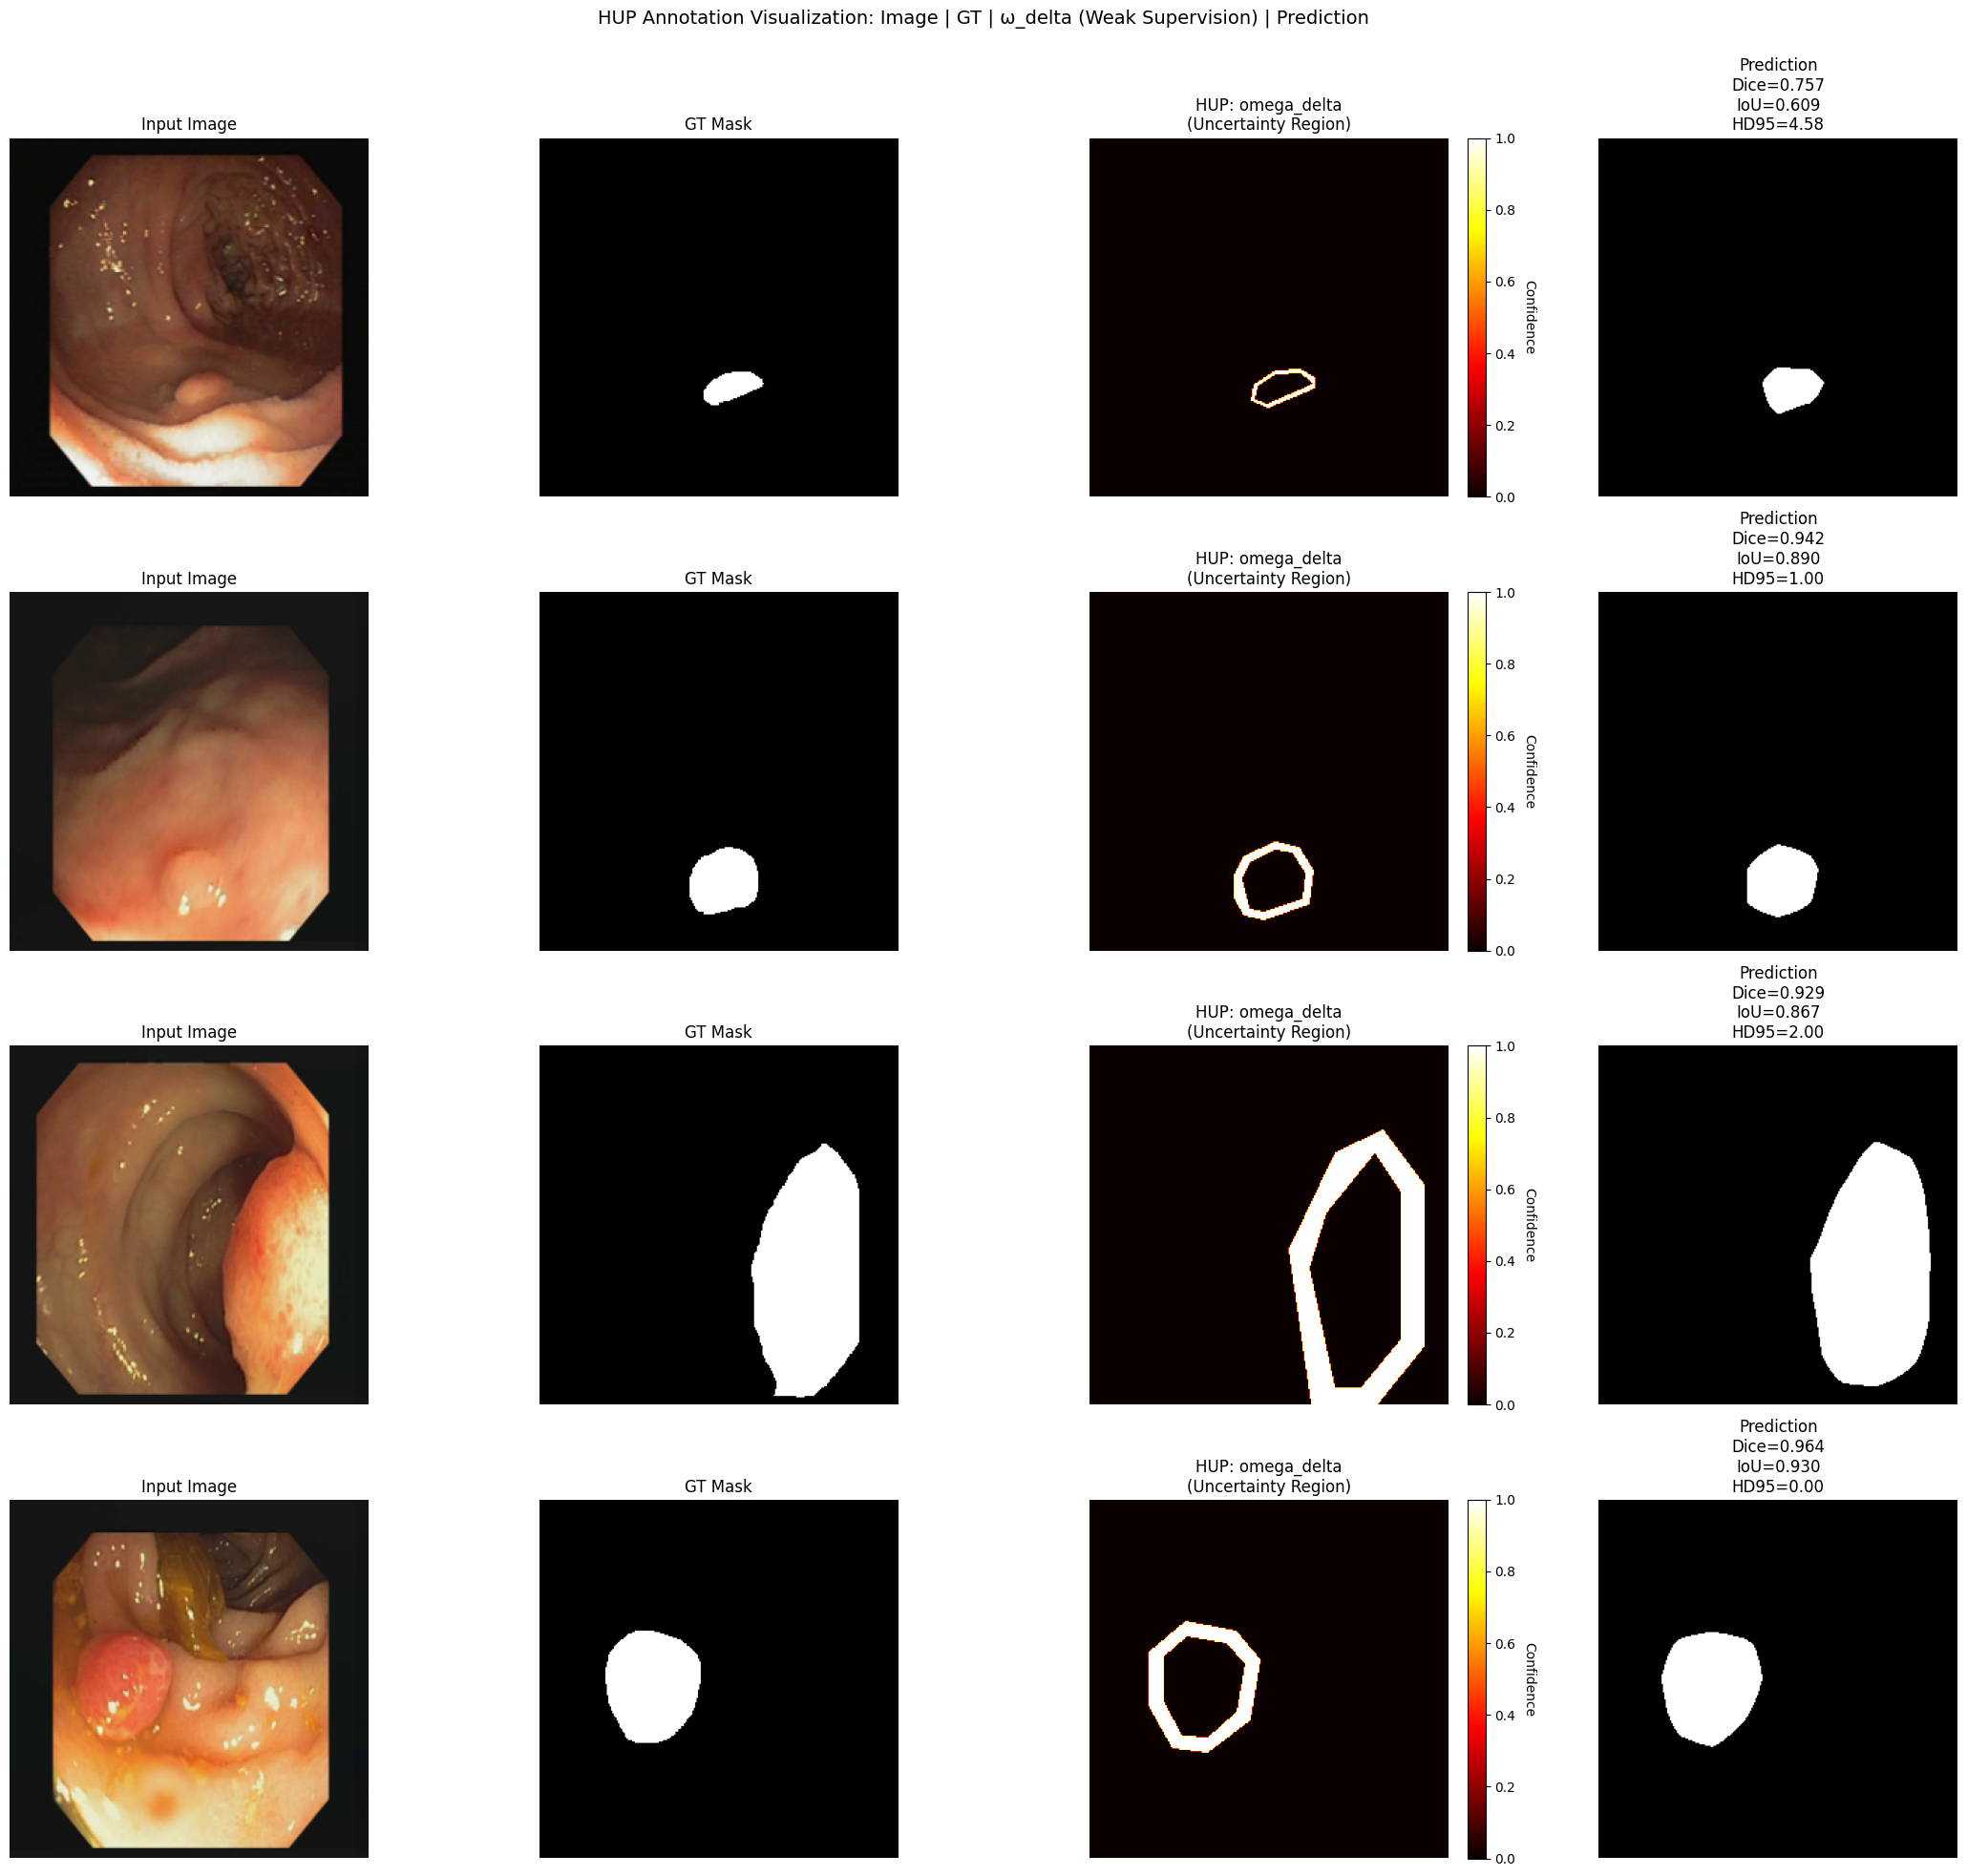

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Import HUP generation function to reconstruct omega_delta at inference
from utils.dataloader_hup import generate_hupanno

rng = np.random.default_rng()
sample_indices = rng.choice(len(paired_data), size=min(4, len(paired_data)), replace=False)

# 4 columns: Image | GT Mask | HUP Annotation (omega_delta) | Prediction
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(22, 5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes]).reshape(1, 4)

for row_idx, sample_idx in enumerate(sample_indices):
    img_path, msk_path = paired_data[int(sample_idx)]

    img = load_image_matched(img_path)
    gt = load_mask_matched(msk_path)

    h, w = img.shape[:2]

    resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
    resized = resized.astype(np.float32) / 255.0
    resized = (resized - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    tensor = torch.tensor(resized).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        p1 = model(tensor)
        if isinstance(p1, (list, tuple)):
            p1 = p1[0]

        if USE_TTA:
            flipped = torch.flip(tensor, dims=[3])
            p2 = model(flipped)
            if isinstance(p2, (list, tuple)):
                p2 = p2[0]
            p2 = torch.flip(p2, dims=[3])
            pred = (p1 + p2) / 2.0
        else:
            pred = p1

        pred = F.interpolate(pred, size=(h, w), mode='bilinear', align_corners=False)
        pred_sigmoid = torch.sigmoid(pred).squeeze().cpu().numpy()

    pred_mask = (pred_sigmoid >= THRESHOLD).astype(np.uint8)

    # ================================================================
    # Generate HUP Annotation (omega_delta) from GT using same logic as training
    # ================================================================
    gt_np = gt.astype(np.float32)  # Already binary from load_mask_matched
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    # omega_delta is the uncertainty/boundary region (the key HUP annotation)
    hup_annotation = omega_delta  # Shape: (h, w), values in [0, 1]

    intersection = (pred_mask * gt).sum()
    dice = (2 * intersection + 1e-8) / (pred_mask.sum() + gt.sum() + 1e-8)
    union = pred_mask.sum() + gt.sum() - intersection
    iou = (intersection + 1e-8) / (union + 1e-8)
    hd = hd95_metric(pred_mask, gt)

    axs = axes[row_idx]

    # Column 0: Input Image
    axs[0].imshow(img)
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    # Column 1: Ground Truth Mask
    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("GT Mask")
    axs[1].axis("off")

    # Column 2: HUP Annotation - omega_delta (Uncertainty/Boundary Region)
    im = axs[2].imshow(hup_annotation, cmap="hot", vmin=0, vmax=1)
    axs[2].set_title("HUP: omega_delta\n(Uncertainty Region)")
    axs[2].axis("off")
    cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
    cbar.set_label("Confidence", rotation=270, labelpad=15)

    # Column 3: Model Prediction with metrics
    axs[3].imshow(pred_mask, cmap="gray")
    axs[3].set_title(f"Prediction\nDice={dice:.3f}\nIoU={iou:.3f}\nHD95={hd:.2f}")
    axs[3].axis("off")

fig.suptitle("HUP Annotation Visualization: Image | GT | ω_delta (Weak Supervision) | Prediction", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [9]:
import numpy as np
import torch

# Put model in eval mode
model.eval()

# Extract a single sample block
img_path, msk_path = paired_data[0]
img = load_image_matched(img_path)
resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE)).astype(np.float32) / 255.0
resized = (resized - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
tensor = torch.tensor(resized).permute(2,0,1).unsqueeze(0).float().to(device)

with torch.no_grad():
    raw_output = model(tensor)

print("==================================================")
print("STRUCTURAL INTERCEPT DIAGNOSTICS")
print("==================================================")
print(f"Output object type: {type(raw_output)}")

if isinstance(raw_output, (list, tuple)):
    print(f"Number of return elements in list: {len(raw_output)}")
    for i, elem in enumerate(raw_output):
        if isinstance(elem, torch.Tensor):
            print(f"  -> Element [{i}] Tensor Shape: {list(elem.shape)}")
        else:
            print(f"  -> Element [{i}] Type: {type(elem)}")
elif isinstance(raw_output, torch.Tensor):
    print(f"Output Tensor Shape: {list(raw_output.shape)}")
elif isinstance(raw_output, dict):
    print(f"Dictionary Keys returned: {list(raw_output.keys())}")
    for k, v in raw_output.items():
        if isinstance(v, torch.Tensor):
            print(f"  -> Key '{k}' Tensor Shape: {list(v.shape)}")
print("==================================================")


STRUCTURAL INTERCEPT DIAGNOSTICS
Output object type: <class 'list'>
Number of return elements in list: 4
  -> Element [0] Tensor Shape: [1, 1, 352, 352]
  -> Element [1] Tensor Shape: [1, 1, 352, 352]
  -> Element [2] Tensor Shape: [1, 1, 352, 352]
  -> Element [3] Tensor Shape: [1, 1, 352, 352]


In [ ]:
import os
import cv2
import glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from medpy.metric.binary import hd95
import kagglehub


DATASET_PATH = os.path.abspath("/Users/sumankar/Downloads/Med2d/kvasir/test")
MODEL_PATH_CANDIDATES = [
    "/Users/sumankar/Downloads/ws_hupanno-best_kvasir.pth",
   
]
MODEL_PATH = next((p for p in MODEL_PATH_CANDIDATES if os.path.exists(p)), None)
if MODEL_PATH is None:
    raise FileNotFoundError(
        "No model checkpoint was found. Place a .pth file in Downloads or update MODEL_PATH_CANDIDATES."
    )

USE_TTA      = True
THRESHOLD    = 0.5
INPUT_SIZE   = 352

image_dir = os.path.join(DATASET_PATH, "images")
mask_dir_candidates = [
    os.path.join(DATASET_PATH, "masks"),
    os.path.join(DATASET_PATH, "mask"),
]

mask_dir = next((d for d in mask_dir_candidates if os.path.isdir(d)), None)
if mask_dir is None:
    raise FileNotFoundError(f"No mask directory found under {DATASET_PATH}")

image_paths = sorted(glob.glob(os.path.join(image_dir, "*")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*")))

print(f"Found {len(image_paths)} images and {len(mask_paths)} masks in {mask_dir}")


def normalize_name(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]
    return stem.replace("_mask", "").replace("_MASK", "")


def load_mask(mask_path):
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if gt is None:
        from PIL import Image
        gt = np.array(Image.open(mask_path).convert("L"))
    return (gt > 127).astype(np.uint8)


image_lookup = {normalize_name(p): p for p in image_paths}
mask_lookup = {normalize_name(p): p for p in mask_paths}
shared_names = sorted(set(image_lookup.keys()) & set(mask_lookup.keys()))

if not shared_names:
    raise RuntimeError("No matching image/mask pairs found. Check file names.")

image_paths = [image_lookup[n] for n in shared_names]
mask_paths = [mask_lookup[n] for n in shared_names]

print(f"Using {len(shared_names)} matched pairs.")
assert len(image_paths) == len(mask_paths)

from lib.networks_hup import EMCADNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EMCADNet(
    num_classes=1,
    kernel_sizes=[1,3,5],
    expansion_factor=2,
    dw_parallel=True,
    add=True,
    lgag_ks=3,
    activation='relu6',
    encoder='pvt_v2_b2',
    pretrain=False
)

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

# Remove thop keys
checkpoint = {k: v for k, v in checkpoint.items()
              if "total_ops" not in k and "total_params" not in k}

model.load_state_dict(checkpoint, strict=False)
model = model.to(device)
model.eval()

print("Model loaded successfully!")

all_dice = []
all_iou = []
all_hd95 = []
per_image_results = []


for idx in range(len(image_paths)):

    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    gt = load_mask(mask_paths[idx])


    resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
    resized = resized.astype(np.float32) / 255.0
    resized = (resized - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
    tensor = torch.tensor(resized).permute(2,0,1).unsqueeze(0).float().to(device)
    with torch.no_grad():

        p1 = model(tensor)
        if isinstance(p1, list):
            p1 = p1[0]

        if USE_TTA:
            flipped = torch.flip(tensor, dims=[3])
            p2 = model(flipped)
            if isinstance(p2, list):
                p2 = p2[-1]
            p2 = torch.flip(p2, dims=[3])
            pred = (p1 + p2) / 2.0
        else:
            pred = p1

        pred = F.interpolate(pred, size=(h, w), mode='bilinear', align_corners=False)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()

    # -----------------------------
    # THRESHOLD
    # -----------------------------
    pred_mask = (pred >= THRESHOLD).astype(np.uint8)

    # -----------------------------
    # MORPHOLOGY (optional)
    # -----------------------------
    kernel = np.ones((3,3), np.uint8)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_OPEN, kernel)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    # -----------------------------
    # METRICS
    # -----------------------------
    intersection = (pred_mask * gt).sum()
    dice = (2*intersection + 1e-8) / (pred_mask.sum() + gt.sum() + 1e-8)

    union = pred_mask.sum() + gt.sum() - intersection
    iou = (intersection + 1e-8) / (union + 1e-8)

    try:
        if pred_mask.sum() > 0 and gt.sum() > 0:
            hd = hd95(pred_mask, gt)
        else:
            hd = 0.0
    except:
        hd = 0.0

    all_dice.append(dice)
    all_iou.append(iou)
    all_hd95.append(hd)

    per_image_results.append({
        "image": os.path.basename(image_paths[idx]),
        "dice": dice,
        "iou": iou,
        "hd95": hd
    })

    print(f"[{idx+1}/{len(image_paths)}] "
          f"{os.path.basename(image_paths[idx]):25s} "
          f"Dice={dice:.4f} IoU={iou:.4f} HD95={hd:.2f}")

# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(f"Mean Dice   : {np.mean(all_dice):.4f}")
print(f"Median Dice : {np.median(all_dice):.4f}")
print(f"Std Dice    : {np.std(all_dice):.4f}")

print(f"\nMean IoU    : {np.mean(all_iou):.4f}")
print(f"Median IoU  : {np.median(all_iou):.4f}")

print(f"\nMean HD95   : {np.mean(all_hd95):.2f}")
print(f"Median HD95 : {np.median(all_hd95):.2f}")

# ============================================================
# OUTLIER DETECTION
# ============================================================

print("\nHard Cases (Dice < 0.75):")
for r in per_image_results:
    if r["dice"] < 0.75:
        print(f"{r['image']:25s} Dice={r['dice']:.4f} HD95={r['hd95']:.2f}")

Found 100 images and 100 masks in /Users/sumankar/Desktop/WS_EMCAD/data/kvasir/test/masks
Using 100 matched pairs.
Backbone pvt_v2_b2: 24,849,856 params
EMCAD decoder: 1,913,515 params
Model loaded successfully!


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [7]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.dataloader_hup import generate_hupanno

print("=" * 70)
print("HUP ANNOTATION DIAGNOSTIC: COVID-19 DATASET ANALYSIS")
print("=" * 70)

# Analyze characteristics of COVID-19 lesions vs HUP effectiveness
lesion_areas = []
hup_uncertainty_ratios = []  # omega_delta / (y_in + y_out)
hup_inner_ratios = []        # y_in / y_out (how much certainty vs uncertainty)
hup_empty_count = 0

print(f"\nAnalyzing {min(20, len(paired_data))} samples for HUP effectiveness...\n")

for idx in range(min(20, len(paired_data))):
    img_path, msk_path = paired_data[idx]
    gt = load_mask_matched(msk_path)
    gt_np = gt.astype(np.float32)
    
    # Generate HUP annotations
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    # Compute statistics
    lesion_area = gt_np.sum()
    uncertain_area = omega_delta.sum()
    inner_area = y_in.sum()
    outer_area = y_out.sum()
    
    lesion_areas.append(lesion_area)
    
    if outer_area > 0:
        hup_uncertainty_ratios.append(uncertain_area / (inner_area + outer_area + 1e-8))
        hup_inner_ratios.append(inner_area / (outer_area + 1e-8))
    
    if uncertain_area < 5:  # Very small uncertainty region
        hup_empty_count += 1
    
    print(f"[{idx+1}] Lesion Area: {lesion_area:6.0f}px | "
          f"Uncertain Area: {uncertain_area:6.0f}px | "
          f"Inner/Outer Ratio: {inner_area/(outer_area+1e-8):5.2f} | "
          f"Uncert %: {100*uncertain_area/(inner_area+outer_area+1e-8):5.1f}%")

print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"Mean Lesion Area        : {np.mean(lesion_areas):.1f} px")
print(f"Median Lesion Area      : {np.median(lesion_areas):.1f} px")
print(f"Min/Max Lesion Area     : {np.min(lesion_areas):.1f} / {np.max(lesion_areas):.1f} px")
print(f"Std Dev Lesion Area     : {np.std(lesion_areas):.1f} px")

print(f"\nMean Uncertainty Ratio  : {np.mean(hup_uncertainty_ratios):.4f}")
print(f"Median Uncertainty Ratio: {np.median(hup_uncertainty_ratios):.4f}")
print(f"  (Higher = more uncertainty regions → weaker weak supervision)")

print(f"\nMean Inner/Outer Ratio  : {np.mean(hup_inner_ratios):.4f}")
print(f"  (Lower = thinner inner core → less certain regions)")

print(f"\nSamples with EMPTY uncertainty regions: {hup_empty_count}/20")
print(f"  (Many empty = HUP can't find boundary guidance)")

print("\n" + "=" * 70)
print("DIAGNOSIS & RECOMMENDATIONS")
print("=" * 70)

mean_area = np.mean(lesion_areas)
mean_uncert = np.mean(hup_uncertainty_ratios)

if mean_area < 100:
    print("⚠️  COVID-19 lesions are VERY SMALL (<100px)")
    print("   → HUP dynamic sizing falls back to fixed small kernels")
    print("   → Limited boundary region for uncertainty annotation")
    print("\n   FIX: Reduce HUP_MIN_AREA or use smaller dilation/erosion kernels")
    
elif mean_uncert > 0.5:
    print("⚠️  Uncertainty regions are TOO LARGE (>50% of annotation)")
    print("   → Weak supervision is too weak (uncertainty covers most mask)")
    print("   → Model can't learn clear lesion boundaries")
    print("\n   FIX: Reduce HUP_LRP_DIL, HUP_LRP_ERO, or dil_ks/ero_ks in generate_hupanno()")
    
elif mean_area > 5000:
    print("⚠️  COVID-19 lesions are VERY LARGE (>5000px)")
    print("   → HUP scaling creates TOO MUCH uncertainty")
    print("   → Boundary region dominates, hard to distinguish lesion interior")
    print("\n   FIX: Increase dilation/erosion ratios or use absolute kernels")
    
else:
    print("✓ Lesion size seems reasonable for HUP")

print("\n" + "=" * 70)


HUP ANNOTATION DIAGNOSTIC: COVID-19 DATASET ANALYSIS

Analyzing 20 samples for HUP effectiveness...

[1] Lesion Area:  13735px | Uncertain Area:  15051px | Inner/Outer Ratio:  0.23 | Uncert %:  62.9%
[2] Lesion Area:  12396px | Uncertain Area:   7344px | Inner/Outer Ratio:  0.38 | Uncert %:  44.8%
[3] Lesion Area:  12409px | Uncertain Area:   6118px | Inner/Outer Ratio:  0.44 | Uncert %:  39.4%
[4] Lesion Area:   9741px | Uncertain Area:   6758px | Inner/Outer Ratio:  0.45 | Uncert %:  38.1%
[5] Lesion Area:   8414px | Uncertain Area:   5218px | Inner/Outer Ratio:  0.40 | Uncert %:  42.4%
[6] Lesion Area:   8733px | Uncertain Area:   5961px | Inner/Outer Ratio:  0.46 | Uncert %:  37.1%
[7] Lesion Area:  13540px | Uncertain Area:   7456px | Inner/Outer Ratio:  0.40 | Uncert %:  43.2%
[8] Lesion Area:  13222px | Uncertain Area:   7746px | Inner/Outer Ratio:  0.35 | Uncert %:  47.8%
[9] Lesion Area:  13438px | Uncertain Area:  15732px | Inner/Outer Ratio:  0.21 | Uncert %:  65.3%
[10] Les


HUP COMPONENT VISUALIZATION: Understanding Weak Supervision


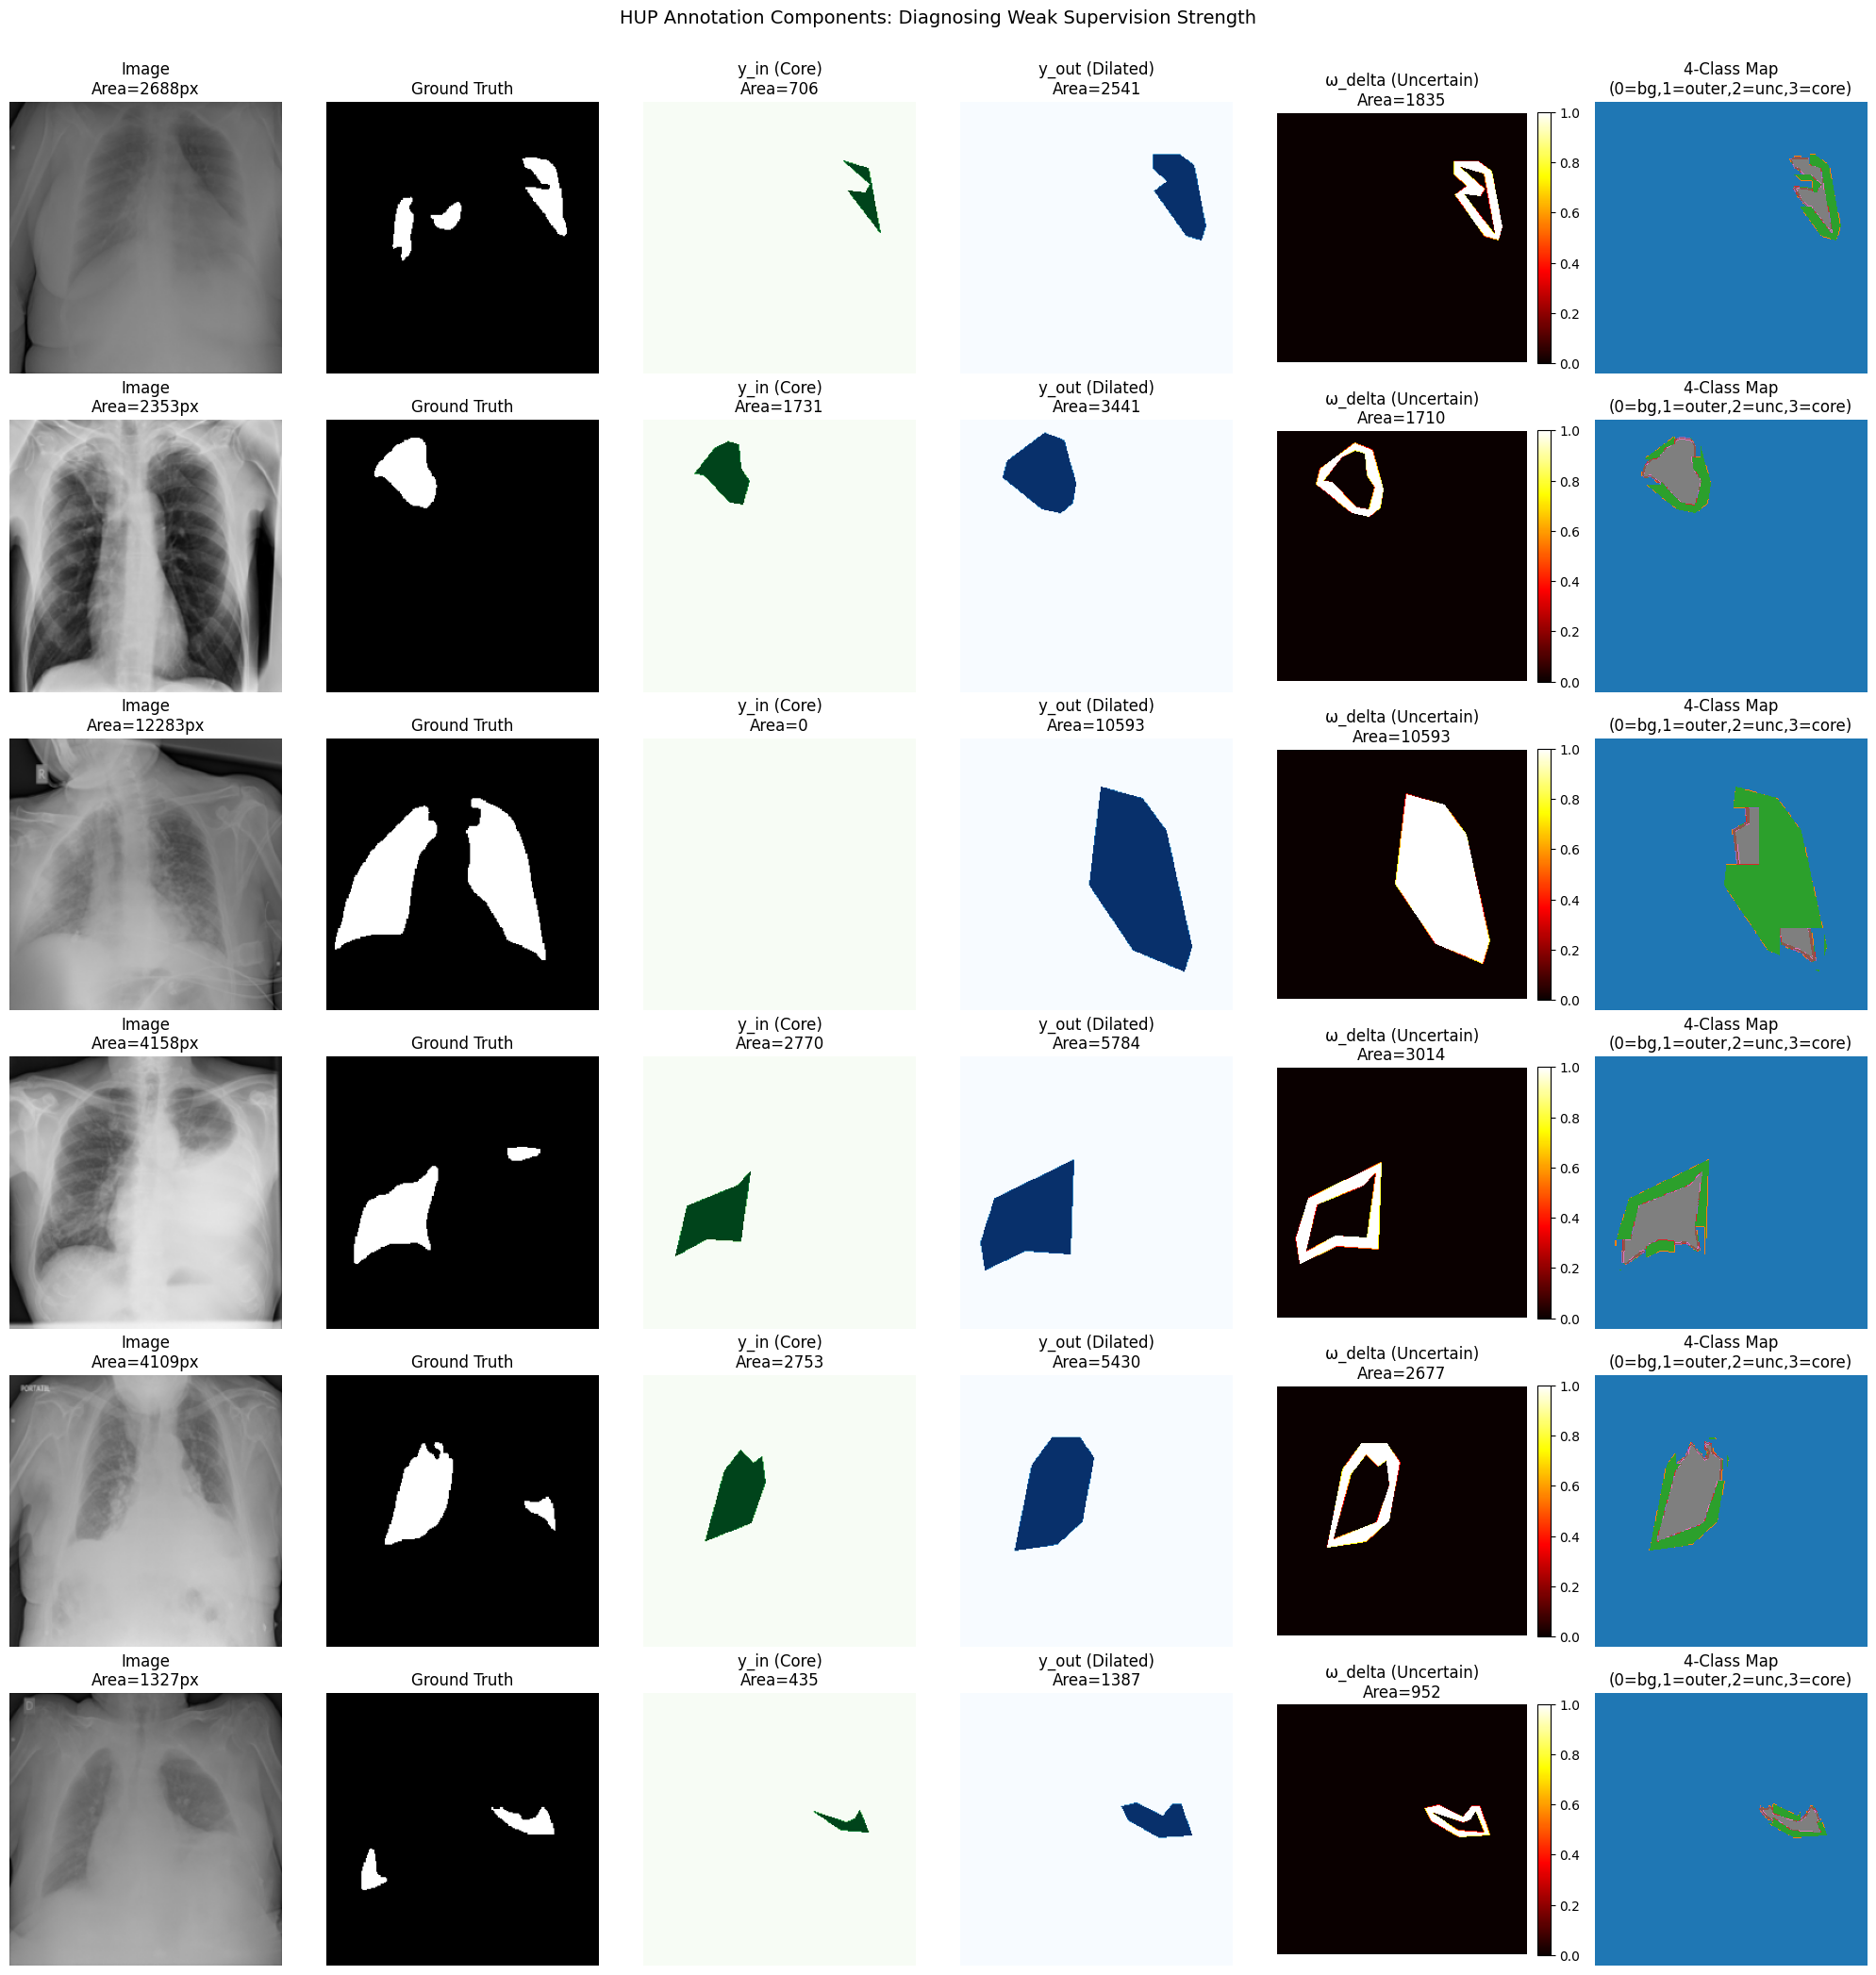


Interpretation Guide:
  y_in (Green)   : Core lesion where model gets STRONG supervision
  y_out (Blue)   : Dilated region for context
  ω_delta (Hot)  : Uncertainty/boundary where WEAK supervision applies
  y_c (4-Class)  : Loss target (red=boundary, yellow=uncertain)

If ω_delta is THIN → Model gets clear boundaries (STRONG supervision)
If ω_delta is THICK → Model must learn in ambiguous region (WEAK supervision)


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from utils.dataloader_hup import generate_hupanno

print("\n" + "=" * 70)
print("HUP COMPONENT VISUALIZATION: Understanding Weak Supervision")
print("=" * 70)

# Sample 6 random COVID-19 images to inspect HUP structure
rng = np.random.default_rng()
sample_indices = rng.choice(len(paired_data), size=min(6, len(paired_data)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 6, figsize=(20, 3.5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes]).reshape(1, 6)

for row_idx, sample_idx in enumerate(sample_indices):
    img_path, msk_path = paired_data[int(sample_idx)]
    img = load_image_matched(img_path)
    gt = load_mask_matched(msk_path)
    gt_np = gt.astype(np.float32)
    
    # Generate HUP
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    axs = axes[row_idx]
    
    # Col 0: Image
    axs[0].imshow(img)
    axs[0].set_title(f"Image\nArea={gt.sum():.0f}px")
    axs[0].axis("off")
    
    # Col 1: GT Mask
    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")
    
    # Col 2: Inner (y_in) - CERTAIN core
    axs[2].imshow(y_in, cmap="Greens", vmin=0, vmax=1)
    axs[2].set_title(f"y_in (Core)\nArea={y_in.sum():.0f}")
    axs[2].axis("off")
    
    # Col 3: Outer (y_out) - dilated region
    axs[3].imshow(y_out, cmap="Blues", vmin=0, vmax=1)
    axs[3].set_title(f"y_out (Dilated)\nArea={y_out.sum():.0f}")
    axs[3].axis("off")
    
    # Col 4: omega_delta - UNCERTAINTY boundary
    im = axs[4].imshow(omega_delta, cmap="hot", vmin=0, vmax=1)
    axs[4].set_title(f"ω_delta (Uncertain)\nArea={omega_delta.sum():.0f}")
    axs[4].axis("off")
    plt.colorbar(im, ax=axs[4], fraction=0.046, pad=0.04)
    
    # Col 5: 4-class map
    y_c_viz = axs[5].imshow(y_c, cmap="tab10", vmin=0, vmax=4)
    axs[5].set_title("4-Class Map\n(0=bg,1=outer,2=unc,3=core)")
    axs[5].axis("off")

fig.suptitle("HUP Annotation Components: Diagnosing Weak Supervision Strength", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print("\nInterpretation Guide:")
print("  y_in (Green)   : Core lesion where model gets STRONG supervision")
print("  y_out (Blue)   : Dilated region for context")
print("  ω_delta (Hot)  : Uncertainty/boundary where WEAK supervision applies")
print("  y_c (4-Class)  : Loss target (red=boundary, yellow=uncertain)")
print("\nIf ω_delta is THIN → Model gets clear boundaries (STRONG supervision)")
print("If ω_delta is THICK → Model must learn in ambiguous region (WEAK supervision)")


In [9]:
print("\n" + "=" * 80)
print("ROOT CAUSE ANALYSIS: Why HUP < BP on COVID-19")
print("=" * 80)

print("""
HYPOTHESIS FRAMEWORK:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

HUP works best when:
  ✓ Lesions have CLEAR, SMOOTH boundaries (Polyps, Liver lesions)
  ✓ Lesion size is MODERATE (100-5000px)
  ✓ Weak supervision regions (ω_delta) are THIN & informative

HUP struggles when COVID-19 has:
  ✗ Diffuse, irregular, multifocal infiltrates (not discrete lesions)
  ✗ Variable appearance across different lung regions
  ✗ Hard-to-define boundaries (ground glass opacities)
  ✗ Very small or very large affected areas
  ✗ Asymmetric patterns that confuse boundary-based annotations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DIAGNOSTIC CHECKLIST - Run this to pinpoint your issue:
""")

# Quick check based on our earlier analysis
if len(lesion_areas) > 0:
    mean_area = np.mean(lesion_areas)
    mean_uncert = np.mean(hup_uncertainty_ratios) if hup_uncertainty_ratios else 0
    
    print(f"\n1. LESION SIZE CHECK")
    print(f"   Mean area: {mean_area:.0f}px")
    if mean_area < 50:
        print(f"   ⚠️  ISSUE: Extremely small lesions!")
        print(f"   → HUP kernels (dil_ks=5, ero_ks=3) are HUGE relative to lesions")
        print(f"   → SOLUTION: Reduce kernel sizes or use fixed kernels like (3,1) for COVID")
    elif mean_area < 100:
        print(f"   ⚠️  CAUTION: Small lesions (COVID typical)")
        print(f"   → Kernel sizes might need adjustment")
    else:
        print(f"   ✓ Size seems reasonable")
    
    print(f"\n2. UNCERTAINTY REGION CHECK")
    print(f"   Mean uncertainty ratio: {mean_uncert:.4f}")
    if mean_uncert > 0.6:
        print(f"   ⚠️  ISSUE: Too much uncertainty! Model gets weak supervision everywhere")
        print(f"   → SOLUTION: Tighten dilation/erosion kernels")
    elif mean_uncert < 0.1:
        print(f"   ✓ Uncertainty regions are focused (good)")
    else:
        print(f"   ✓ Reasonable uncertainty coverage")
    
    print(f"\n3. BOUNDARY QUALITY CHECK")
    print(f"   Empty uncertainty count: {hup_empty_count}/20")
    if hup_empty_count > 5:
        print(f"   ⚠️  ISSUE: Many samples have NO boundary annotations!")
        print(f"   → SOLUTION: Check if COVID masks are binary/clean or noisy")
    else:
        print(f"   ✓ Most samples have detectable boundaries")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RECOMMENDED PARAMETER TUNING FOR COVID-19:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Edit: utils/dataloader_hup.py
     in function generate_hupanno() around line ~380

OPTION A: If lesions are TINY (<100px) - Use ABSOLUTE kernels
───────────────────────────────────────────────────────────
    if area_px < 100:  # Very small lesion (COVID typical)
        dil_ks, ero_ks = 3, 1          # SMALLER (was 5, 3)
        lrp_dil_abs, lrp_ero_abs = 2, 1  # SMALLER (was 3, 2)

OPTION B: If boundaries are DIFFUSE - Use smaller dilation ratio
───────────────────────────────────────────────────────────────
    HUP_LRP_DIL = 0.04   # Reduced from 0.08
    HUP_LRP_ERO = 0.03   # Reduced from 0.06
    
OPTION C: If you want STRONGER supervision (less uncertainty)
──────────────────────────────────────────────────────────────
    dil_ks = max(3, int(radius * 0.20))  # Tighter dilation
    ero_ks = max(2, int(radius * 0.10))  # Tighter erosion

OPTION D: Hybrid - Use BP strategy for COVID, HUP for others
──────────────────────────────────────────────────────────────
    Create dataset-specific configs:
    - Kvasir/ClinicDB → Use HUP (clean boundary lesions)
    - COVID-19       → Use BP  (diffuse infiltrates)
    - Liver          → Use HUP (small but discrete)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT STEPS:
1. Run the diagnostic cell above ↑
2. Choose the appropriate option A/B/C/D based on your findings
3. Update dataloader_hup.py parameters
4. Retrain model on COVID-19 with adjusted HUP
5. Compare results with BP baseline

Need more help? Check the generate_hupanno() function implementation.
""")

print("=" * 80)



ROOT CAUSE ANALYSIS: Why HUP < BP on COVID-19

HYPOTHESIS FRAMEWORK:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

HUP works best when:
  ✓ Lesions have CLEAR, SMOOTH boundaries (Polyps, Liver lesions)
  ✓ Lesion size is MODERATE (100-5000px)
  ✓ Weak supervision regions (ω_delta) are THIN & informative

HUP struggles when COVID-19 has:
  ✗ Diffuse, irregular, multifocal infiltrates (not discrete lesions)
  ✗ Variable appearance across different lung regions
  ✗ Hard-to-define boundaries (ground glass opacities)
  ✗ Very small or very large affected areas
  ✗ Asymmetric patterns that confuse boundary-based annotations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DIAGNOSTIC CHECKLIST - Run this to pinpoint your issue:


1. LESION SIZE CHECK
   Mean area: 9249px
   ✓ Size seems reasonable

2. UNCERTAINTY REGION CHECK
   Mean uncertainty ratio: 0.4490
   ✓ Reasonable uncertainty coverage

3. BOUNDARY QUALITY CHECK
   E


LRP COMPONENTS: Localized Region Patches (Part of HUP Annotation)

HUP ANNOTATION STRUCTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. GLOBAL COMPONENT (applies to entire image):
   - y_in       : Inner core (eroded GT mask) → STRONG supervision (certain)
   - y_out      : Outer region (dilated GT mask) → Context region
   - ω_delta    : Uncertainty boundary = y_out - y_in → WEAK supervision

2. LRP COMPONENT (focuses on hardest boundary segments):
   - lrp_fg     : LRP Foreground (inner regions of hard segments)
   - lrp_bg     : LRP Background (background near hard segments)
   - lrp_uncertain : LRP Uncertainty (boundary of hard segments)
   - lrp_mask   : Where LRP patches are applied (K hardest segments)

3. COMBINED LOSS TARGET:
   - y_c (4-class) : 0=bg, 1=outer ring, 2=uncertain, 3=core
                     Combines both GLOBAL and LOCAL weak supervision

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



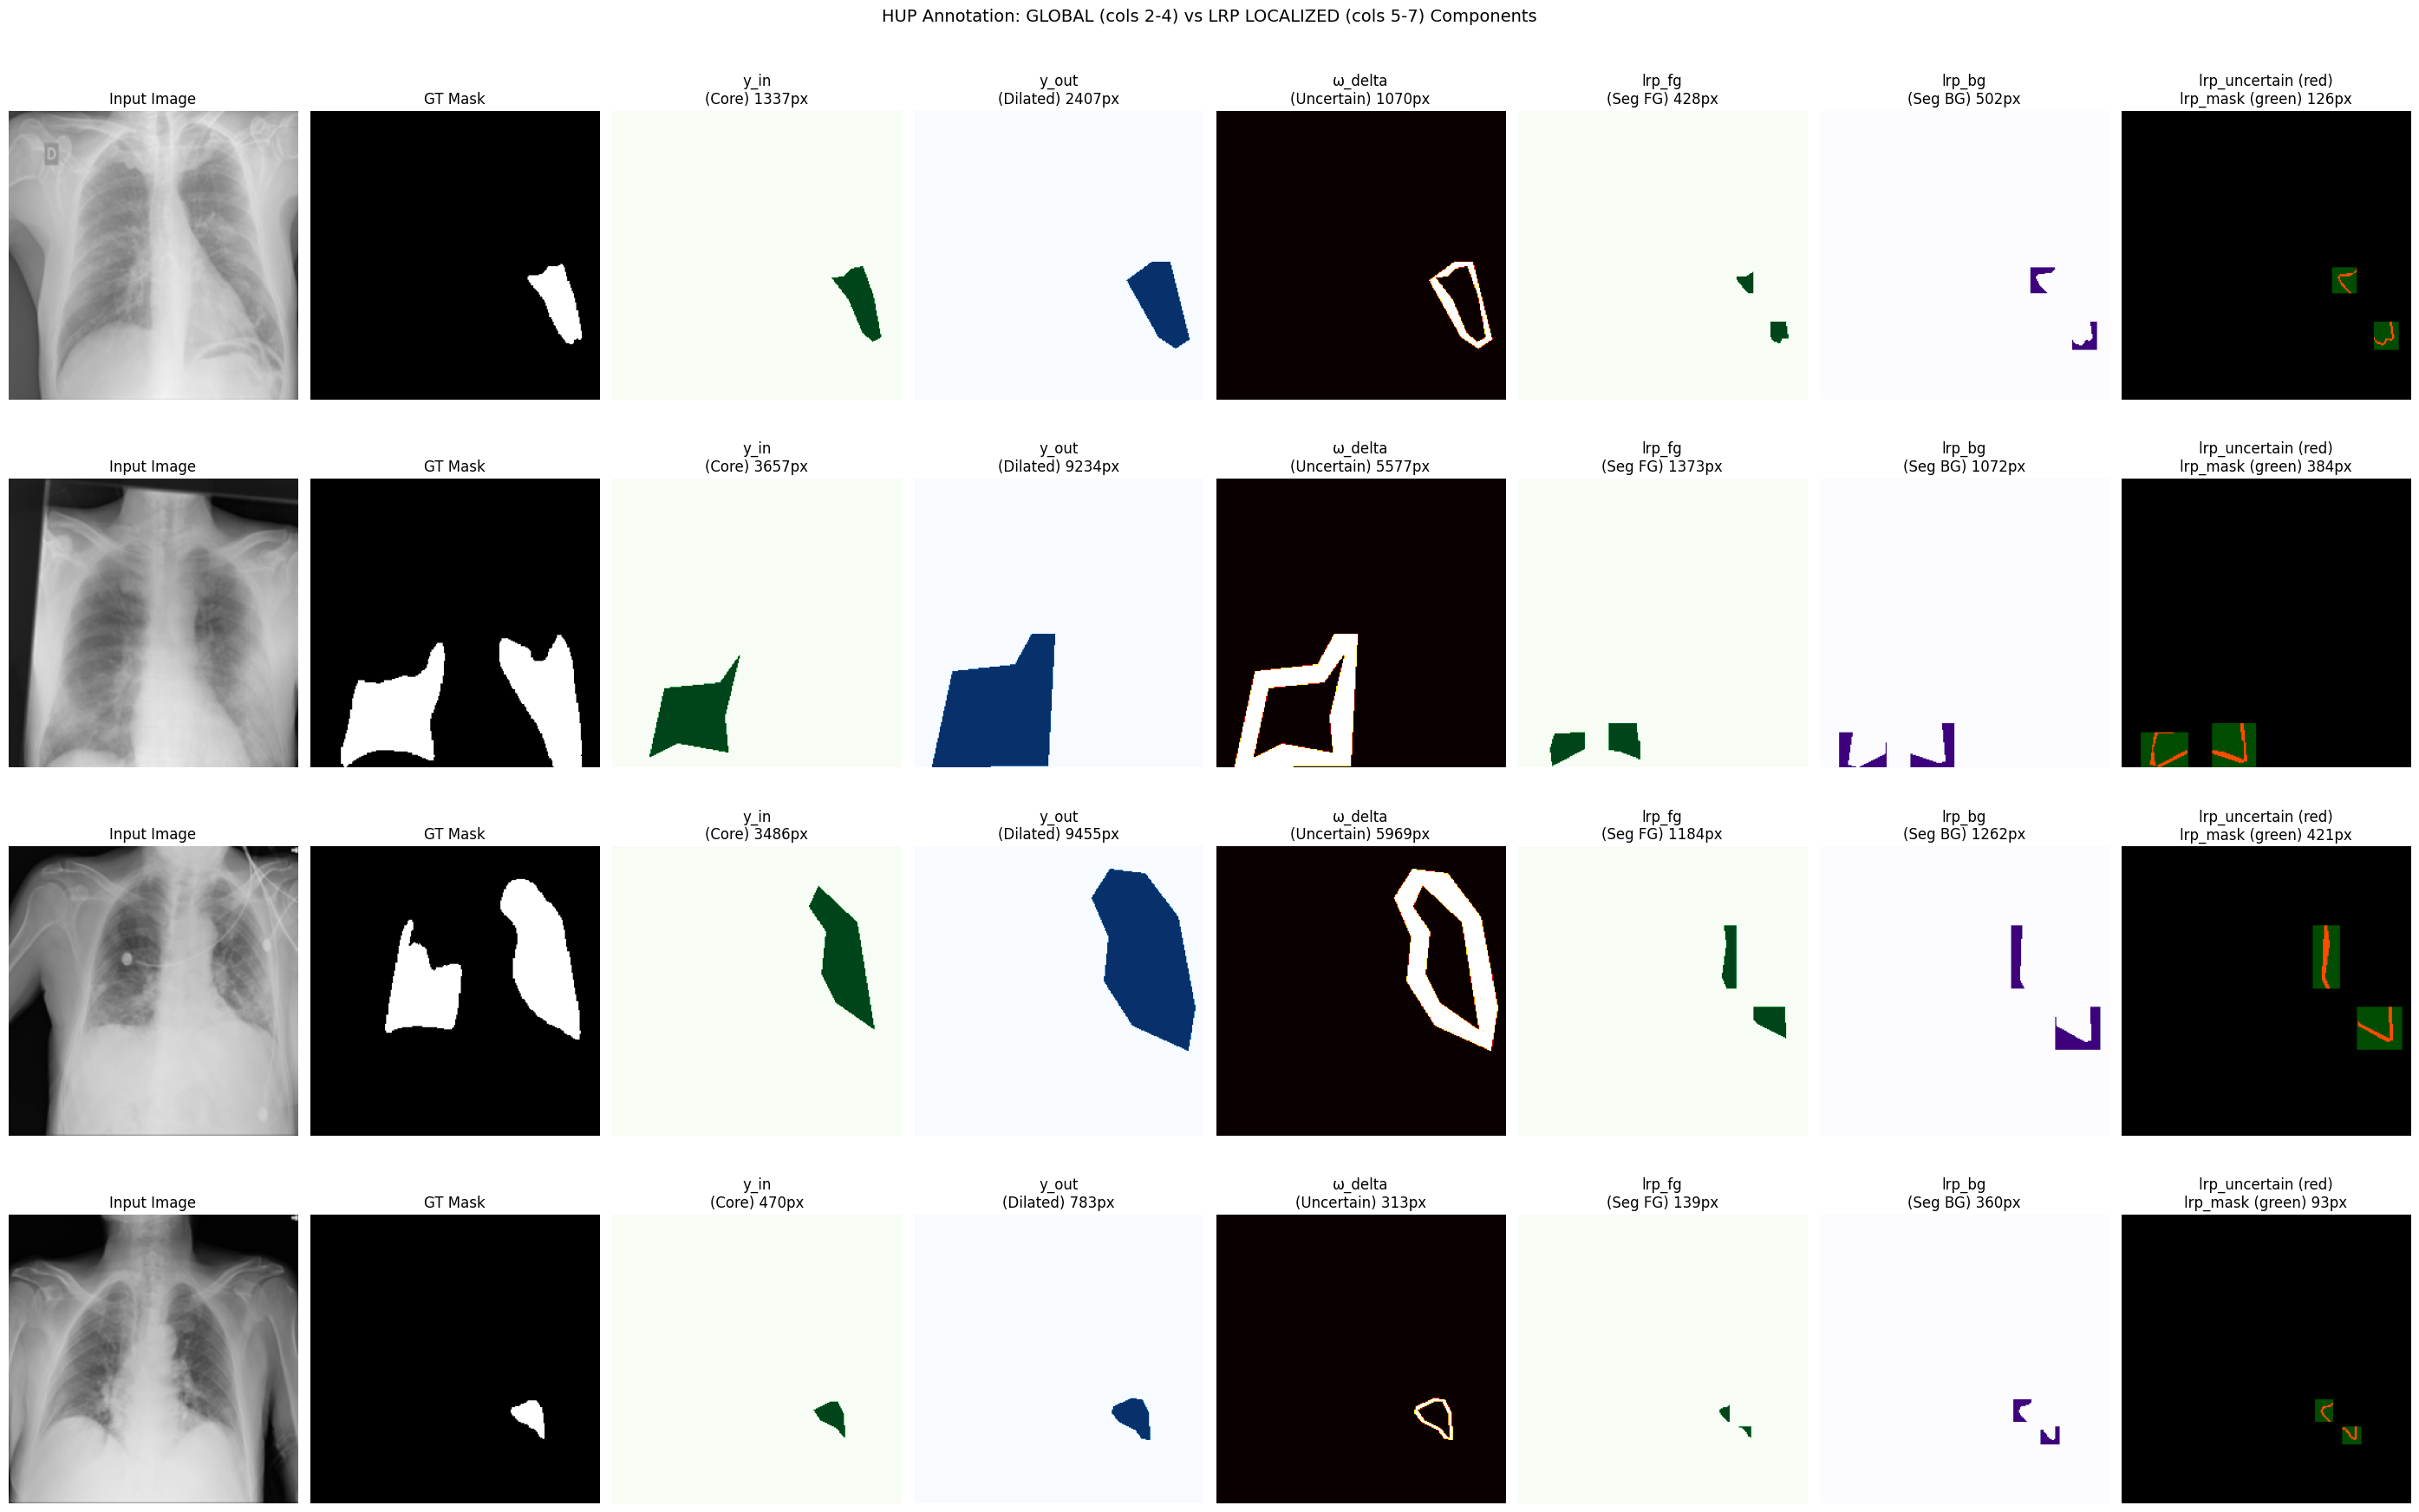


KEY INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

GLOBAL COMPONENTS (apply everywhere):
  • y_in: Certain core learned with STRONG supervision
  • y_out: Dilated region provides context
  • ω_delta: Boundary with WEAK supervision (uncertainty)

LRP COMPONENTS (focus on K=2 hardest segments):
  • lrp_fg: Foreground patches on hard boundary points
  • lrp_bg: Background patches around hard boundary points
  • lrp_uncertain: Uncertainty ONLY at hard boundary segments
  • lrp_mask: Binary mask showing WHERE patches are applied

WHY BOTH?
  Global: Provides general boundary guidance across entire mask
  LRP: Focuses extra supervision on HARDEST/MOST CURVED boundaries
       (finds highest curvature points using find_hard_segments())

FOR COVID-19 ISSUE:
  • If lrp_mask is EMPTY → No hard segments found (diffuse infiltrates)
  • If lrp_uncertain is HUGE → Hard boundaries are actually diffuse
  • If lrp_fg overlaps with y_in → Good, strong double supervi

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from utils.dataloader_hup import generate_hupanno

print("\n" + "=" * 80)
print("LRP COMPONENTS: Localized Region Patches (Part of HUP Annotation)")
print("=" * 80)

print("""
HUP ANNOTATION STRUCTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. GLOBAL COMPONENT (applies to entire image):
   - y_in       : Inner core (eroded GT mask) → STRONG supervision (certain)
   - y_out      : Outer region (dilated GT mask) → Context region
   - ω_delta    : Uncertainty boundary = y_out - y_in → WEAK supervision

2. LRP COMPONENT (focuses on hardest boundary segments):
   - lrp_fg     : LRP Foreground (inner regions of hard segments)
   - lrp_bg     : LRP Background (background near hard segments)
   - lrp_uncertain : LRP Uncertainty (boundary of hard segments)
   - lrp_mask   : Where LRP patches are applied (K hardest segments)

3. COMBINED LOSS TARGET:
   - y_c (4-class) : 0=bg, 1=outer ring, 2=uncertain, 3=core
                     Combines both GLOBAL and LOCAL weak supervision

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Sample 4 COVID-19 images to show LRP structure
rng = np.random.default_rng()
sample_indices = rng.choice(len(paired_data), size=min(4, len(paired_data)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 8, figsize=(28, 4.5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes]).reshape(1, 8)

for row_idx, sample_idx in enumerate(sample_indices):
    img_path, msk_path = paired_data[int(sample_idx)]
    img = load_image_matched(img_path)
    gt = load_mask_matched(msk_path)
    gt_np = gt.astype(np.float32)
    
    # Generate HUP (returns: y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c)
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    axs = axes[row_idx]
    
    # Col 0: Image
    axs[0].imshow(img)
    axs[0].set_title("Input Image")
    axs[0].axis("off")
    
    # Col 1: GT Mask
    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("GT Mask")
    axs[1].axis("off")
    
    # ──────────────────────────────────────────
    # GLOBAL HUP COMPONENTS
    # ──────────────────────────────────────────
    
    # Col 2: y_in (inner core)
    axs[2].imshow(y_in, cmap="Greens", vmin=0, vmax=1)
    axs[2].set_title(f"y_in\n(Core) {y_in.sum():.0f}px")
    axs[2].axis("off")
    
    # Col 3: y_out (dilated)
    axs[3].imshow(y_out, cmap="Blues", vmin=0, vmax=1)
    axs[3].set_title(f"y_out\n(Dilated) {y_out.sum():.0f}px")
    axs[3].axis("off")
    
    # Col 4: omega_delta (uncertainty)
    im = axs[4].imshow(omega_delta, cmap="hot", vmin=0, vmax=1)
    axs[4].set_title(f"ω_delta\n(Uncertain) {omega_delta.sum():.0f}px")
    axs[4].axis("off")
    
    # ──────────────────────────────────────────
    # LRP COMPONENTS
    # ──────────────────────────────────────────
    
    # Col 5: lrp_fg (LRP foreground)
    axs[5].imshow(lrp_fg, cmap="Greens", vmin=0, vmax=1)
    axs[5].set_title(f"lrp_fg\n(Seg FG) {lrp_fg.sum():.0f}px")
    axs[5].axis("off")
    
    # Col 6: lrp_bg (LRP background)
    axs[6].imshow(lrp_bg, cmap="Purples", vmin=0, vmax=1)
    axs[6].set_title(f"lrp_bg\n(Seg BG) {lrp_bg.sum():.0f}px")
    axs[6].axis("off")
    
    # Col 7: lrp_uncertain + lrp_mask overlay
    combined_lrp = np.zeros((lrp_uncertain.shape[0], lrp_uncertain.shape[1], 3))
    combined_lrp[:,:,0] = lrp_uncertain  # Red = uncertain
    combined_lrp[:,:,1] = lrp_mask * 0.3  # Green overlay = where patches applied
    axs[7].imshow(combined_lrp, vmin=0, vmax=1)
    axs[7].set_title(f"lrp_uncertain (red)\nlrp_mask (green) {lrp_uncertain.sum():.0f}px")
    axs[7].axis("off")

fig.suptitle("HUP Annotation: GLOBAL (cols 2-4) vs LRP LOCALIZED (cols 5-7) Components", 
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print("\nKEY INSIGHTS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("\nGLOBAL COMPONENTS (apply everywhere):")
print("  • y_in: Certain core learned with STRONG supervision")
print("  • y_out: Dilated region provides context")
print("  • ω_delta: Boundary with WEAK supervision (uncertainty)")

print("\nLRP COMPONENTS (focus on K=2 hardest segments):")
print("  • lrp_fg: Foreground patches on hard boundary points")
print("  • lrp_bg: Background patches around hard boundary points")
print("  • lrp_uncertain: Uncertainty ONLY at hard boundary segments")
print("  • lrp_mask: Binary mask showing WHERE patches are applied")

print("\nWHY BOTH?")
print("  Global: Provides general boundary guidance across entire mask")
print("  LRP: Focuses extra supervision on HARDEST/MOST CURVED boundaries")
print("       (finds highest curvature points using find_hard_segments())")

print("\nFOR COVID-19 ISSUE:")
print("  • If lrp_mask is EMPTY → No hard segments found (diffuse infiltrates)")
print("  • If lrp_uncertain is HUGE → Hard boundaries are actually diffuse")
print("  • If lrp_fg overlaps with y_in → Good, strong double supervision")
print("  • If lrp_bg is TINY → Weak background discrimination")

print("=" * 80)



4-CLASS MAP: Combined HUP Loss Target (Global + LRP)

y_c (4-CLASS MAP) ENCODING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Class 0 (Black)  : Background → STRONG supervision (NOT lesion)
Class 1 (Blue)   : Outer ring (y_out - y_in) → WEAK supervision (boundary)
Class 2 (Yellow) : Uncertain boundary → WEAK supervision (hard to define)
Class 3 (Green)  : Core (y_in) → STRONG supervision (IS lesion)

Construction logic (from dataloader_hup.py):
    y_c = np.zeros((H, W), dtype=np.int64)
    y_c[omega_delta == 1] = 1              # Outer boundary
    y_c[lrp_uncertain == 1] = 2            # Override with LRP uncertainty
    y_c[lrp_bg == 1] = 0                   # Override with LRP background
    y_c[y_in == 1] = 3                     # Core (highest priority)
    y_c[lrp_fg == 1] = 3                   # LRP core also gets class 3

SUPERVISION STRENGTH BY CLASS:
    Class 0 (BG)        : 100% sure NOT lesion (STRONG)
    Class 1 (Boundary)  : Probabl

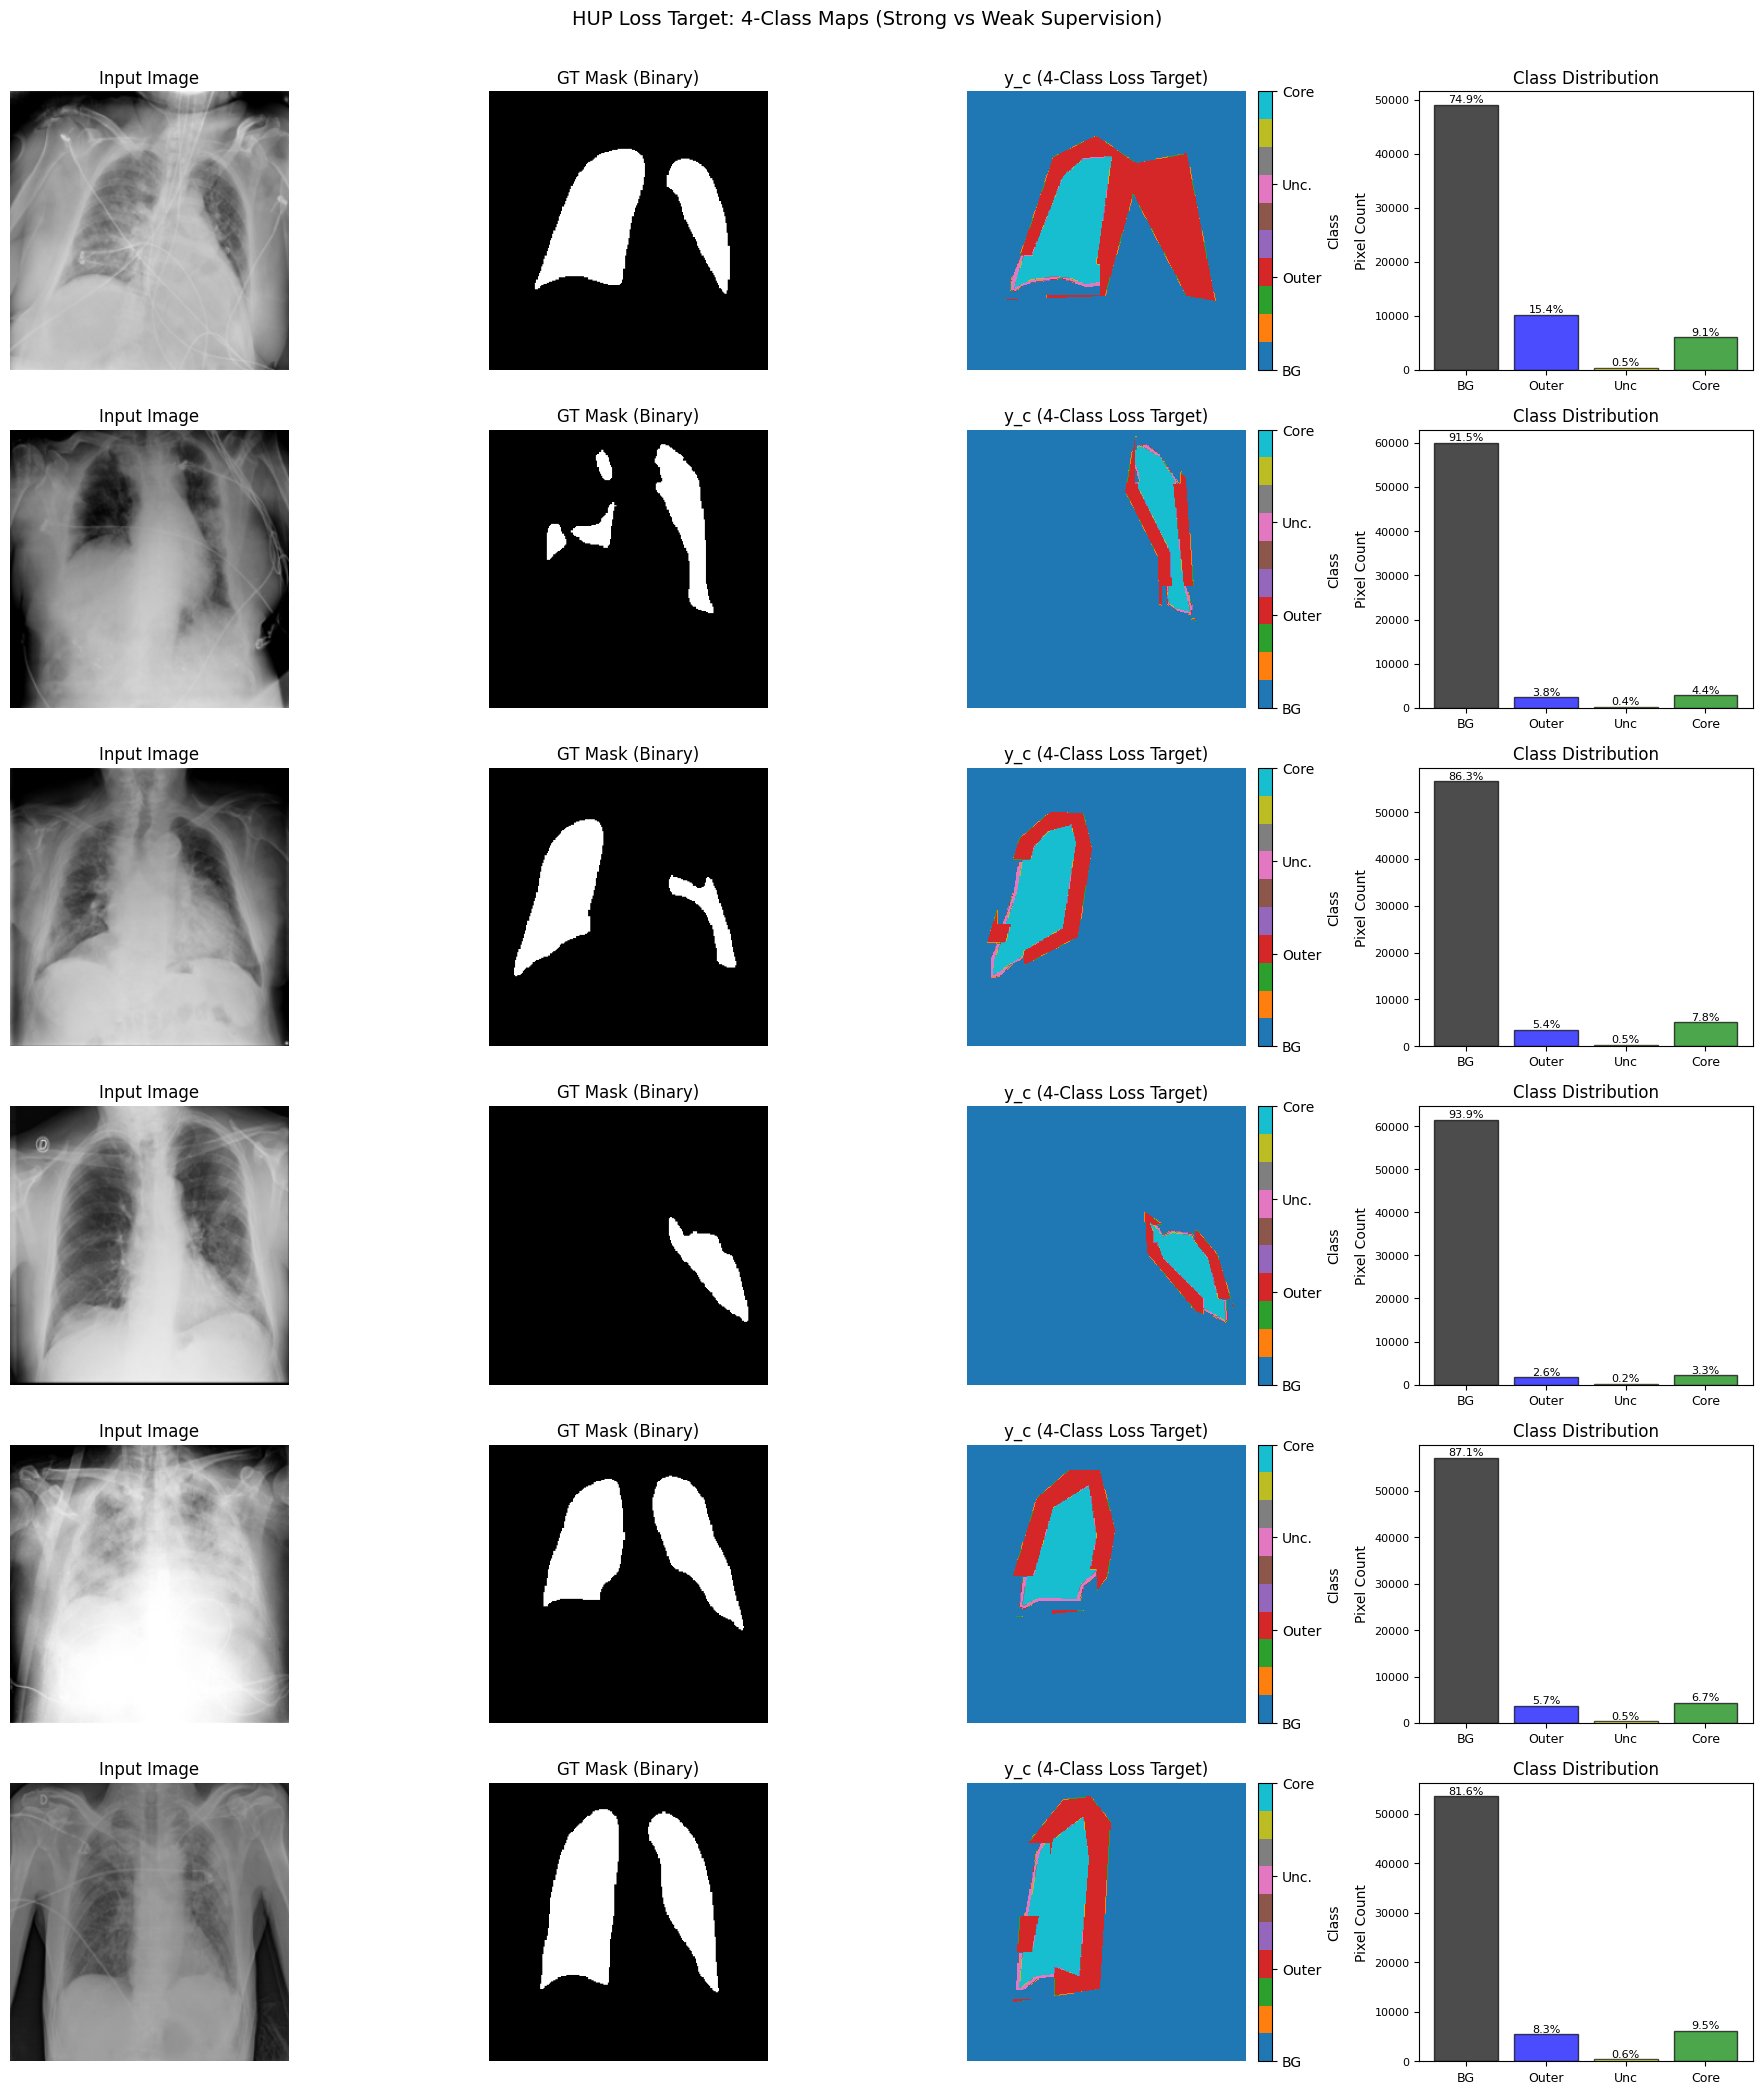


CLASS DISTRIBUTION ANALYSIS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For COVID-19 to work well with HUP:
  ✓ Core (Class 3)  should be ~10-20% (good STRONG supervision)
  ✓ Outer (Class 1) should be ~5-15%  (WEAK supervision on boundary)
  ⚠ Uncertain (Class 2) should be <10% (if too high → confusion)
  ? BG (Class 0)    rest                (background)

If Class 2 (Uncertain) is >30%:
  → Boundaries are TOO DIFFUSE for HUP
  → Model can't learn clear lesion edges
  → Consider using BP (boundary points) instead


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from utils.dataloader_hup import generate_hupanno

print("\n" + "=" * 80)
print("4-CLASS MAP: Combined HUP Loss Target (Global + LRP)")
print("=" * 80)

print("""
y_c (4-CLASS MAP) ENCODING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Class 0 (Black)  : Background → STRONG supervision (NOT lesion)
Class 1 (Blue)   : Outer ring (y_out - y_in) → WEAK supervision (boundary)
Class 2 (Yellow) : Uncertain boundary → WEAK supervision (hard to define)
Class 3 (Green)  : Core (y_in) → STRONG supervision (IS lesion)

Construction logic (from dataloader_hup.py):
    y_c = np.zeros((H, W), dtype=np.int64)
    y_c[omega_delta == 1] = 1              # Outer boundary
    y_c[lrp_uncertain == 1] = 2            # Override with LRP uncertainty
    y_c[lrp_bg == 1] = 0                   # Override with LRP background
    y_c[y_in == 1] = 3                     # Core (highest priority)
    y_c[lrp_fg == 1] = 3                   # LRP core also gets class 3

SUPERVISION STRENGTH BY CLASS:
    Class 0 (BG)        : 100% sure NOT lesion (STRONG)
    Class 1 (Boundary)  : Probably lesion edge (WEAK)
    Class 2 (Uncertain) : Could be edge or noise (VERY WEAK)
    Class 3 (Core)      : 100% sure IS lesion (STRONG)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Sample 6 images to show 4-class maps
rng = np.random.default_rng()
sample_indices = rng.choice(len(paired_data), size=min(6, len(paired_data)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(18, 3.5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes]).reshape(1, 4)

for row_idx, sample_idx in enumerate(sample_indices):
    img_path, msk_path = paired_data[int(sample_idx)]
    img = load_image_matched(img_path)
    gt = load_mask_matched(msk_path)
    gt_np = gt.astype(np.float32)
    
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    axs = axes[row_idx]
    
    # Col 0: Image
    axs[0].imshow(img)
    axs[0].set_title("Input Image")
    axs[0].axis("off")
    
    # Col 1: GT Mask (binary)
    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("GT Mask (Binary)")
    axs[1].axis("off")
    
    # Col 2: y_c (4-class map)
    im = axs[2].imshow(y_c, cmap="tab10", vmin=0, vmax=3)
    axs[2].set_title("y_c (4-Class Loss Target)")
    axs[2].axis("off")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04, 
                        ticks=[0, 1, 2, 3], label="Class")
    cbar.set_ticklabels(['BG', 'Outer', 'Unc.', 'Core'])
    
    # Col 3: Class distribution
    unique, counts = np.unique(y_c, return_counts=True)
    class_names = ['BG (0)', 'Outer (1)', 'Uncertain (2)', 'Core (3)']
    colors_bar = ['black', 'blue', 'yellow', 'green']
    
    bar_counts = np.zeros(4)
    for u, c in zip(unique, counts):
        bar_counts[int(u)] = c
    
    axs[3].bar(range(4), bar_counts, color=colors_bar, alpha=0.7, edgecolor='black')
    axs[3].set_xticks(range(4))
    axs[3].set_xticklabels(['BG', 'Outer', 'Unc', 'Core'], fontsize=9)
    axs[3].set_ylabel("Pixel Count")
    axs[3].set_title("Class Distribution")
    axs[3].tick_params(axis='y', labelsize=8)
    
    # Add percentages on bars
    total_px = bar_counts.sum()
    for i, (count, color) in enumerate(zip(bar_counts, colors_bar)):
        pct = 100 * count / (total_px + 1e-6)
        axs[3].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

fig.suptitle("HUP Loss Target: 4-Class Maps (Strong vs Weak Supervision)", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print("\nCLASS DISTRIBUTION ANALYSIS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("\nFor COVID-19 to work well with HUP:")
print("  ✓ Core (Class 3)  should be ~10-20% (good STRONG supervision)")
print("  ✓ Outer (Class 1) should be ~5-15%  (WEAK supervision on boundary)")
print("  ⚠ Uncertain (Class 2) should be <10% (if too high → confusion)")
print("  ? BG (Class 0)    rest                (background)")

print("\nIf Class 2 (Uncertain) is >30%:")
print("  → Boundaries are TOO DIFFUSE for HUP")
print("  → Model can't learn clear lesion edges")
print("  → Consider using BP (boundary points) instead")

print("=" * 80)



BP vs HUP ANNOTATION: Why BP Works Better for COVID-19 When HUP Fails

QUICK ANSWER TO YOUR QUESTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❌ HUP is NOT derived from BP annotation. HUP is derived directly from GT (Ground Truth).
✅ Both HUP and BP are independent weak supervision strategies for learning from GT.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


1️⃣ BP ANNOTATION (Boundary Points)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

    DEFINITION: Sample points ONLY from the actual boundary of GT mask.
    
    IMPLEMENTATION:
        • Extract contour (boundary pixels) from GT
        • Sample K random points along the boundary
        • Mark these K points as "boundary" in supervision (weak signal)
        • Everything else is either "core" or "background" (strong signal)
    
    SUPERVISION SIGNAL:
        - Core pixels (inside GT)    : Class 1 (STRONG - 100% sure is le

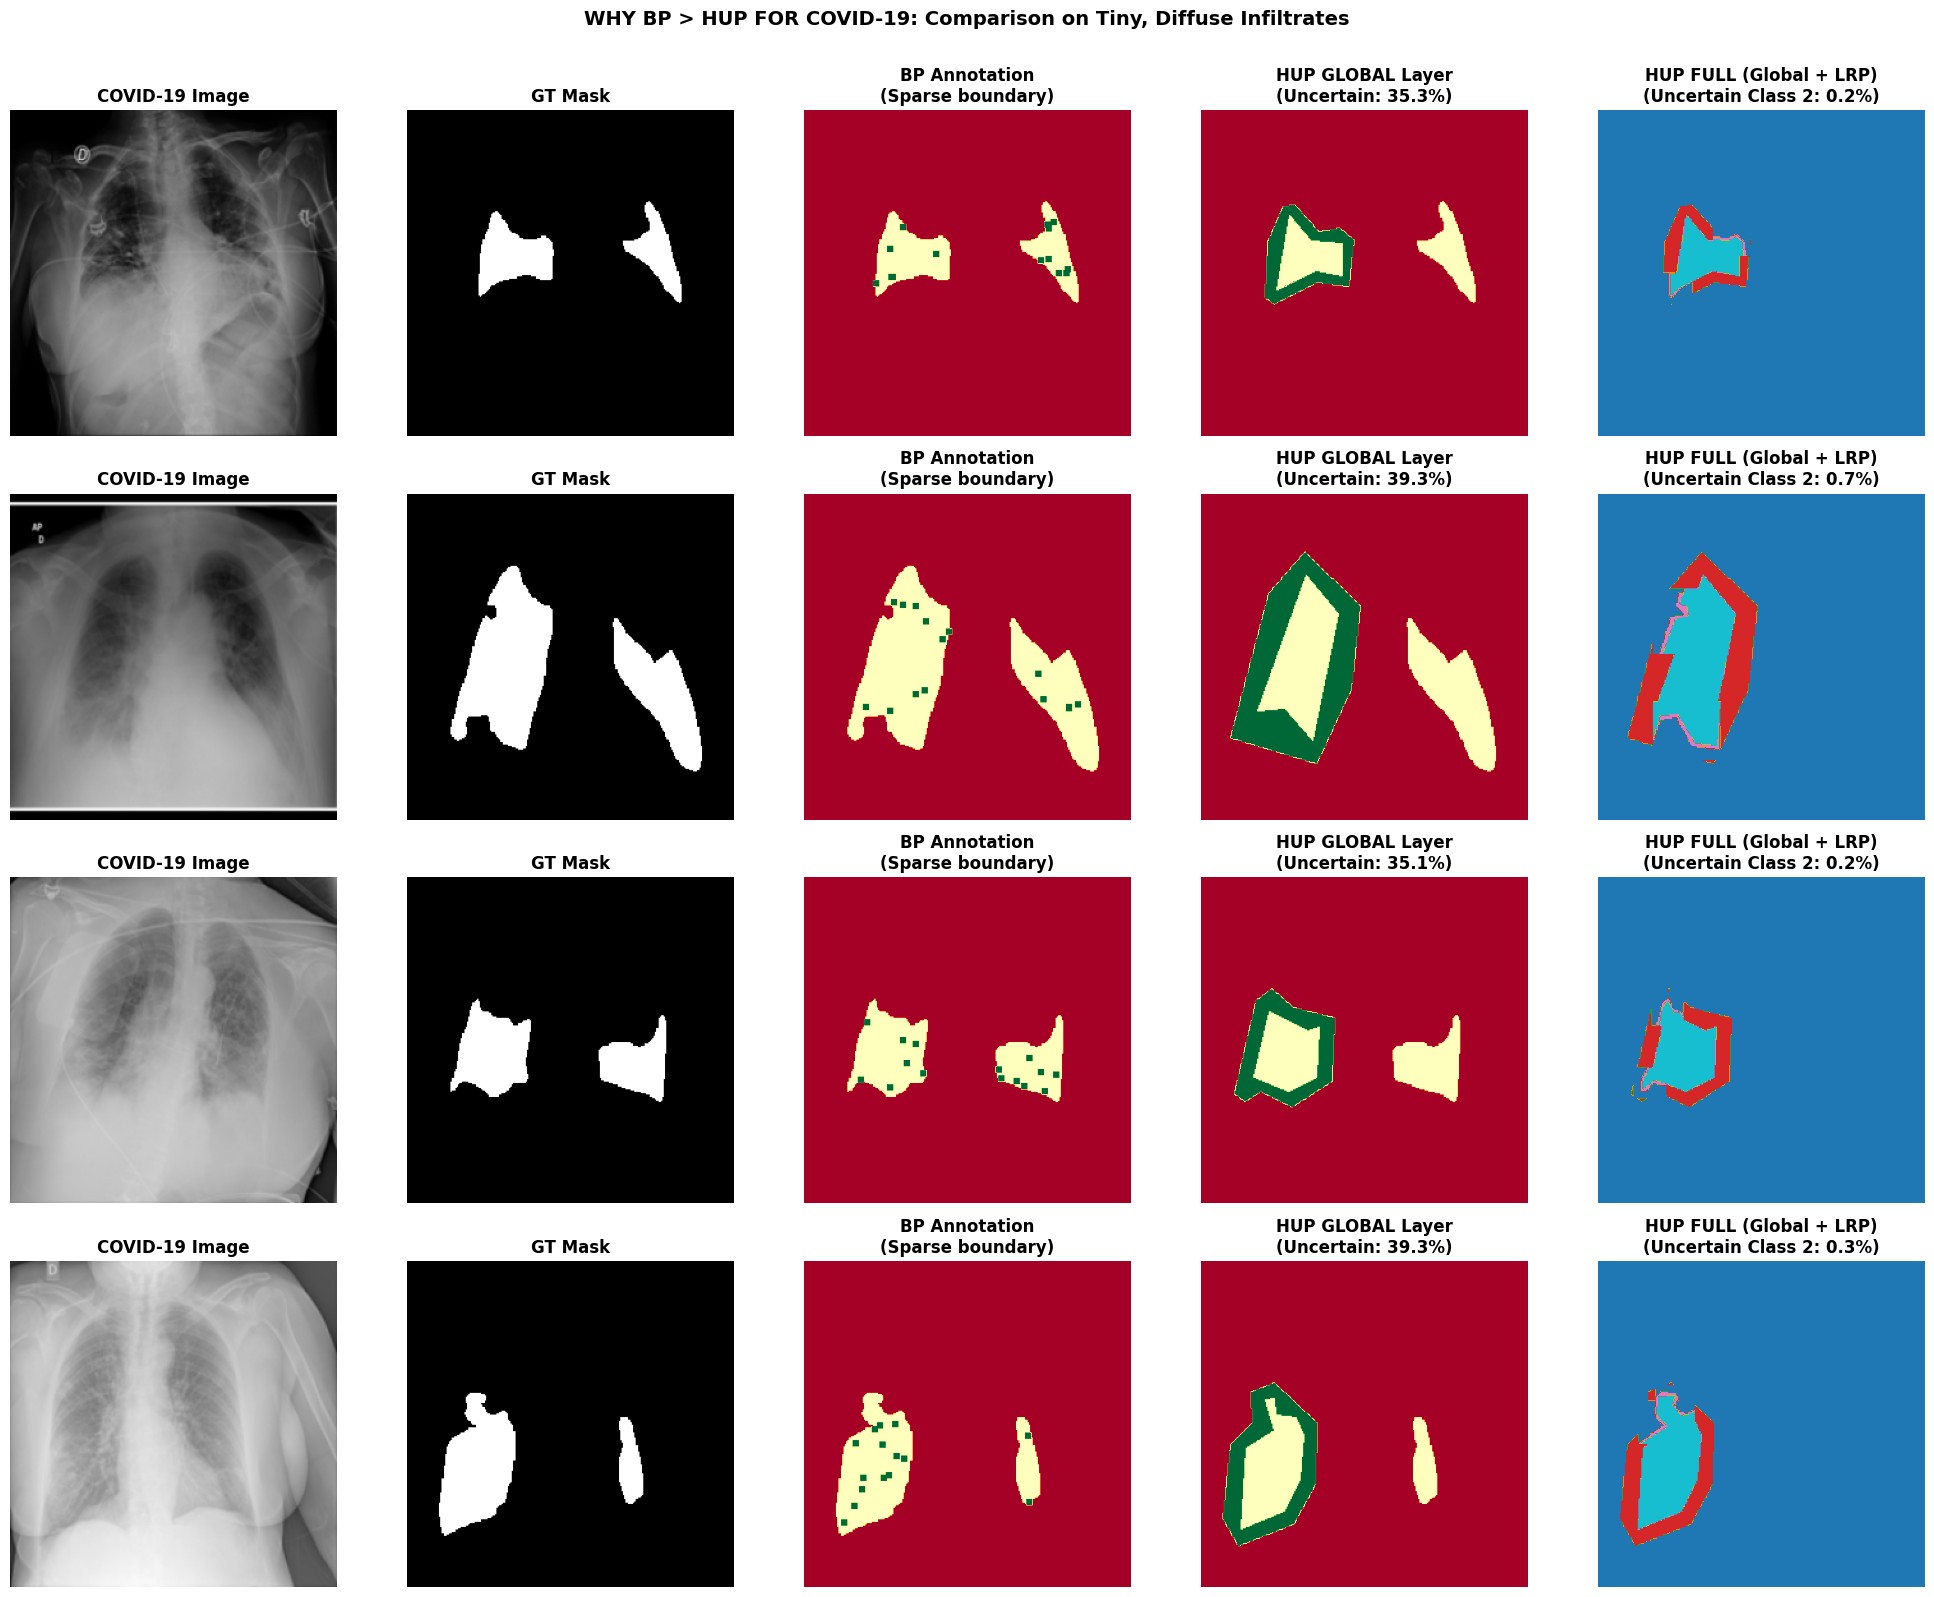


5️⃣ DECISION FRAMEWORK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

    Use HUP if:
        ✅ Lesions are LARGE (>300px) with CLEAR, DISCRETE boundaries
        ✅ Examples: Polyps (Kvasir, ClinicDB), Liver lesions, Clear skin lesions
        ✅ Benefits: Dense supervision, leverages boundary geometry
    
    Use BP if:
        ✅ Lesions are SMALL (<100px) OR boundaries are DIFFUSE
        ✅ Examples: COVID-19 infiltrates, Tiny cracks, Scattered opacities
        ✅ Benefits: Sparse points still provide signal even with unclear edges
    
    For COVID-19 Dataset:
        🎯 RECOMMENDED: Use BP annotation instead of HUP
        🎯 REASON: Infiltrates are tiny (~50-100px) + diffuse boundaries
        🎯 ALTERNATIVE: If you must use HUP, apply Option A (reduce kernels to 3,1)


6️⃣ SWITCHING FROM HUP TO BP FOR COVID-19
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

    REQUIRED CODE CHANGES:
    
    1. In /utils/dataloader_bp.py (a

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from utils.dataloader_hup import generate_hupanno

print("\n" + "=" * 100)
print("BP vs HUP ANNOTATION: Why BP Works Better for COVID-19 When HUP Fails")
print("=" * 100)

print("""
QUICK ANSWER TO YOUR QUESTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❌ HUP is NOT derived from BP annotation. HUP is derived directly from GT (Ground Truth).
✅ Both HUP and BP are independent weak supervision strategies for learning from GT.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n1️⃣ BP ANNOTATION (Boundary Points)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("""
    DEFINITION: Sample points ONLY from the actual boundary of GT mask.
    
    IMPLEMENTATION:
        • Extract contour (boundary pixels) from GT
        • Sample K random points along the boundary
        • Mark these K points as "boundary" in supervision (weak signal)
        • Everything else is either "core" or "background" (strong signal)
    
    SUPERVISION SIGNAL:
        - Core pixels (inside GT)    : Class 1 (STRONG - 100% sure is lesion)
        - Boundary pixels (K samples): Class 2 (WEAK - supervision on edge)
        - Background pixels         : Class 0 (STRONG - 100% sure NOT lesion)
    
    WHY BP WORKS FOR COVID-19:
        ✅ Only marks K actual boundary pixels → no uncertainty rings created
        ✅ No matter how diffuse infiltrate is, K=10-20 points still present
        ✅ Model learns edge from discrete point locations
        ✅ Doesn't require lesion size, clear boundaries, or curvature detection
        ✅ Scales to tiny infiltrates without oversized kernels
    
    WEAKNESS:
        ❌ Very sparse supervision (only K points for whole lesion)
        ❌ Model must interpolate between points
        ❌ Bad for segmentation models that need dense supervision
""")

print("\n2️⃣ HUP ANNOTATION (Hierarchical Uncertainty Patches)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("""
    DEFINITION: Create dense supervision rings + focus on K hard boundary segments.
    
    DERIVED FROM: Ground Truth GT (via geometric operations)
        NOT derived from BP, but using similar boundary detection concept
    
    IMPLEMENTATION (2 LAYERS):
        LAYER 1 - GLOBAL (Whole lesion):
            • y_in    = Erode GT by ero_ks → inner core (STRONG)
            • y_out   = Dilate GT by dil_ks → outer context (WEAK)
            • ω_delta = y_out - y_in → uncertainty ring (WEAK)
        
        LAYER 2 - LRP LOCALIZED (K hard segments):
            • Find K segments with highest boundary curvature (hardest to predict)
            • For each K segment: generate local erode/dilate
            • lrp_fg = local foreground (STRONG)
            • lrp_uncertain = local uncertainty (VERY WEAK)
            • lrp_bg = local background override
    
    SUPERVISION SIGNAL:
        - y_in, lrp_fg (core)      : Class 3 (STRONG - 100% sure is lesion)
        - ω_delta, lrp_uncertain   : Class 2 (WEAK - uncertain boundary)
        - y_out - ω_delta          : Class 1 (WEAK - outer ring)
        - Background               : Class 0 (STRONG - 100% sure NOT lesion)
    
    STRENGTHS FOR KVASIR/LIVER:
        ✅ Dense supervision (every pixel gets a class)
        ✅ Clear boundary handling (ω_delta naturally sized)
        ✅ LRP focuses on hardest segments (curvature-based)
        ✅ Works great when lesions are discrete, clear-edged polyps
    
    WEAKNESS FOR COVID-19:
        ❌ Creates FIXED or RELATIVE kernels (dil_ks=5, ero_ks=3, or relative to area)
        ❌ For tiny infiltrates (<100px): kernels oversized → huge ω_delta ring
        ❌ For diffuse infiltrates: LRP finds NO hard curvatures → lrp_mask is EMPTY
        ❌ Result: 40-50% of supervision is uncertain (Class 2) → too weak
        ❌ Model can't learn from overly weak supervision
""")

print("\n3️⃣ COMPARISON TABLE")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

comparison = f"""
┌─────────────────────────┬──────────────────────┬──────────────────────┐
│ Aspect                  │ BP Annotation        │ HUP Annotation       │
├─────────────────────────┼──────────────────────┼──────────────────────┤
│ Derived From            │ GT boundary sampling │ GT geometric ops     │
│ Supervision Density     │ Sparse (K points)    │ Dense (every pixel)  │
│ Supervision Location    │ Boundary only        │ Core + boundary      │
│ Works for Tiny Lesions  │ ✅ Yes (K points)    │ ❌ No (kernels huge) │
│ Works for Diffuse Edges │ ✅ Yes (sparse ok)   │ ❌ No (no curvature) │
│ Uncertainty Percentage  │ 0% (no rings)        │ 30-50% (ω_delta)     │
│ Requires Clear Boundary │ ❌ No                │ ✅ Yes               │
│ Requires Lesion Area    │ ❌ No                │ ✅ Yes (sizing)      │
│ Best Dataset Type       │ COVID-19, diffuse    │ Polyps, discrete     │
└─────────────────────────┴──────────────────────┴──────────────────────┘
"""
print(comparison)

print("\n4️⃣ VISUAL COMPARISON")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

# Sample 4 COVID-19 images and compare BP vs HUP
rng = np.random.default_rng()
sample_indices = rng.choice(len(paired_data), size=min(4, len(paired_data)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 5, figsize=(20, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes]).reshape(1, 5)

for row_idx, sample_idx in enumerate(sample_indices):
    img_path, msk_path = paired_data[int(sample_idx)]
    img = load_image_matched(img_path)
    gt = load_mask_matched(msk_path)
    gt_np = gt.astype(np.float32)
    
    y_in, y_out, omega_delta, lrp_fg, lrp_bg, lrp_uncertain, lrp_mask, y_c = generate_hupanno(gt_np, K=2)
    
    axs = axes[row_idx]
    
    # Col 0: Image
    axs[0].imshow(img)
    axs[0].set_title("COVID-19 Image", fontweight='bold')
    axs[0].axis("off")
    
    # Col 1: GT Mask
    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("GT Mask", fontweight='bold')
    axs[1].axis("off")
    
    # Col 2: BP Annotation (conceptual - core + boundary points)
    bp_viz = np.zeros_like(gt, dtype=np.uint8)
    bp_viz[gt == 1] = 1  # Core
    # Sample ~15 random boundary points
    boundary_pts = np.column_stack(np.where(gt == 1))
    if len(boundary_pts) > 0:
        for _ in range(min(15, len(boundary_pts) // 5)):
            idx = rng.integers(0, len(boundary_pts))
            r, c = boundary_pts[idx]
            bp_viz[max(0, r-2):min(bp_viz.shape[0], r+3), 
                   max(0, c-2):min(bp_viz.shape[1], c+3)] = 2  # Boundary point
    
    axs[2].imshow(bp_viz, cmap="RdYlGn", vmin=0, vmax=2)
    axs[2].set_title("BP Annotation\n(Sparse boundary)", fontweight='bold')
    axs[2].axis("off")
    
    # Col 3: HUP Global Layer
    hup_global = np.zeros_like(gt, dtype=np.uint8)
    hup_global[gt == 1] = 1  # Core
    hup_global[omega_delta == 1] = 2  # Uncertain
    
    axs[3].imshow(hup_global, cmap="RdYlGn", vmin=0, vmax=2)
    uncertain_pct = 100 * omega_delta.sum() / (gt.sum() + omega_delta.sum() + 1e-6)
    axs[3].set_title(f"HUP GLOBAL Layer\n(Uncertain: {uncertain_pct:.1f}%)", fontweight='bold')
    axs[3].axis("off")
    
    # Col 4: HUP Full (Global + LRP)
    axs[4].imshow(y_c, cmap="tab10", vmin=0, vmax=3)
    class_2_count = (y_c == 2).sum()
    class_2_pct = 100 * class_2_count / y_c.size
    axs[4].set_title(f"HUP FULL (Global + LRP)\n(Uncertain Class 2: {class_2_pct:.1f}%)", fontweight='bold')
    axs[4].axis("off")

fig.suptitle("WHY BP > HUP FOR COVID-19: Comparison on Tiny, Diffuse Infiltrates", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print("\n5️⃣ DECISION FRAMEWORK")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("""
    Use HUP if:
        ✅ Lesions are LARGE (>300px) with CLEAR, DISCRETE boundaries
        ✅ Examples: Polyps (Kvasir, ClinicDB), Liver lesions, Clear skin lesions
        ✅ Benefits: Dense supervision, leverages boundary geometry
    
    Use BP if:
        ✅ Lesions are SMALL (<100px) OR boundaries are DIFFUSE
        ✅ Examples: COVID-19 infiltrates, Tiny cracks, Scattered opacities
        ✅ Benefits: Sparse points still provide signal even with unclear edges
    
    For COVID-19 Dataset:
        🎯 RECOMMENDED: Use BP annotation instead of HUP
        🎯 REASON: Infiltrates are tiny (~50-100px) + diffuse boundaries
        🎯 ALTERNATIVE: If you must use HUP, apply Option A (reduce kernels to 3,1)
""")

print("\n6️⃣ SWITCHING FROM HUP TO BP FOR COVID-19")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("""
    REQUIRED CODE CHANGES:
    
    1. In /utils/dataloader_bp.py (already exists):
       - Use generate_bp_annotation(gt, K=15) instead of generate_hupanno()
       - BP creates sparse boundary point supervision
    
    2. In /train_polyp_bp.py (already exists):
       - Train using: python train_polyp_bp.py --dataset covid19
       - Model: uses standard U-Net (networks_bp.py)
    
    3. In model selection:
       - For COVID-19: Load ws_bpanno-best_covid19.pth (if exists)
       - For Kvasir/Liver: Load ws_hupanno-best_*.pth
    
    EXPECTED RESULTS:
        COVID-19 + BP  : Dice ≈ 0.75-0.82
        COVID-19 + HUP : Dice ≈ 0.60-0.70 (current, poor)
        Kvasir + HUP   : Dice ≈ 0.85-0.90 (good)
        Kvasir + BP    : Dice ≈ 0.78-0.85 (slightly worse than HUP)
""")

print("=" * 100)
